# CrewAI, end to end — a runnable tutorial

Two parts, designed to be run top-to-bottom.

- **Part 1 — the mental model:** Agent, Task, Tool, Crew, Process, Memory,
  Delegation, grounded in the DeepLearning.AI CrewAI notebooks (L2–L7).
  *Conceptual snippets here are Markdown — they illustrate the API, they are
  not meant to execute.*
- **Parts 2–4 — runnable code:** a tiny crew, a tool-using agent, then a full
  local **weather + Text-to-SQL** project that this notebook **writes to disk**
  with `%%writefile` and runs with `uv`.
- **Part 5 — reading traces, debugging, evaluation, and SQL safety.**

> **Runnability contract.** Every *code cell* either runs with **no API key**
> (tool calls, the SQLite DB, assertions, file writers) or is **guarded**: if
> no model is configured it prints the expected output instead of erroring. So
> *Run All* never crashes, with or without a key.

# Part 0 — Setup

**For the local project repo** you use `uv` (no `pip`, no `venv`):

```bash
uv init crew-demo && cd crew-demo
uv add crewai requests python-dotenv
```

**For this notebook's kernel** we install the same deps so the runnable cells
work in Jupyter/Colab. (The DLAI course does the equivalent with
`!pip install crewai==0.28.8`.) This takes ~1 min the first time.

In [ ]:
# Install into THIS notebook's kernel so the runnable cells work.
%pip install -q "crewai>=0.130,<1.0" requests python-dotenv
print("install step done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.2/473.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24

Now a **setup-verification** cell. It checks the install, detects whether a
model is configured, and defines `run_crew(...)` — the guard that makes the
LLM-dependent cells safe to *Run All* even with no key.

In [ ]:
from getpass import getpass
os.environ["OPENAI_API_KEY"] = getpass("Open AI API Key")

Open AI API Key··········


In [ ]:
import os, sys, importlib.metadata as md_, pathlib

# 1. crewai present?
try:
    import crewai
    print("crewai", md_.version("crewai"))
except Exception as e:                       # pragma: no cover
    raise SystemExit(f"crewai import failed — re-run the install cell: {e}")

# 2. is a model configured? (OpenAI key, or a local Ollama model string)
CREWAI_MODEL = os.getenv("CREWAI_MODEL", "openai/gpt-4o-mini")
LLM_READY = bool(os.getenv("OPENAI_API_KEY")) or CREWAI_MODEL.startswith("ollama/")
print("model:", CREWAI_MODEL, "| LLM_READY:", LLM_READY)
if not LLM_READY:
    print("  -> no key found: live crew cells will PRINT EXPECTED OUTPUT, "
          "not call an LLM. Set OPENAI_API_KEY to run them for real.")

def run_crew(crew, inputs, expected="(expected output not provided)"):
    """Run the crew if a model is configured; otherwise show what it would do."""
    if not LLM_READY:
        print("LLM not configured — skipping live run.\nEXPECTED:\n", expected)
        return None
    return crew.kickoff(inputs=inputs)

# 3. one tidy working directory for everything we generate
WORK = pathlib.Path("crewai_demo").resolve()
WORK.mkdir(exist_ok=True)
os.chdir(WORK)
print("working dir:", WORK)

crewai 0.203.2
model: openai/gpt-4o-mini | LLM_READY: True
working dir: /content/crewai_demo/crewai_demo


# Part 1 — The mental model

### From an LLM to an agent

An LLM only predicts the next token — that gets you *content*. The leap to an
**agent** is wrapping that prediction in **cognition**: let the model decide to
call a tool, observe the result, and react. The model **plus a tool-use loop**
*is* the agent.

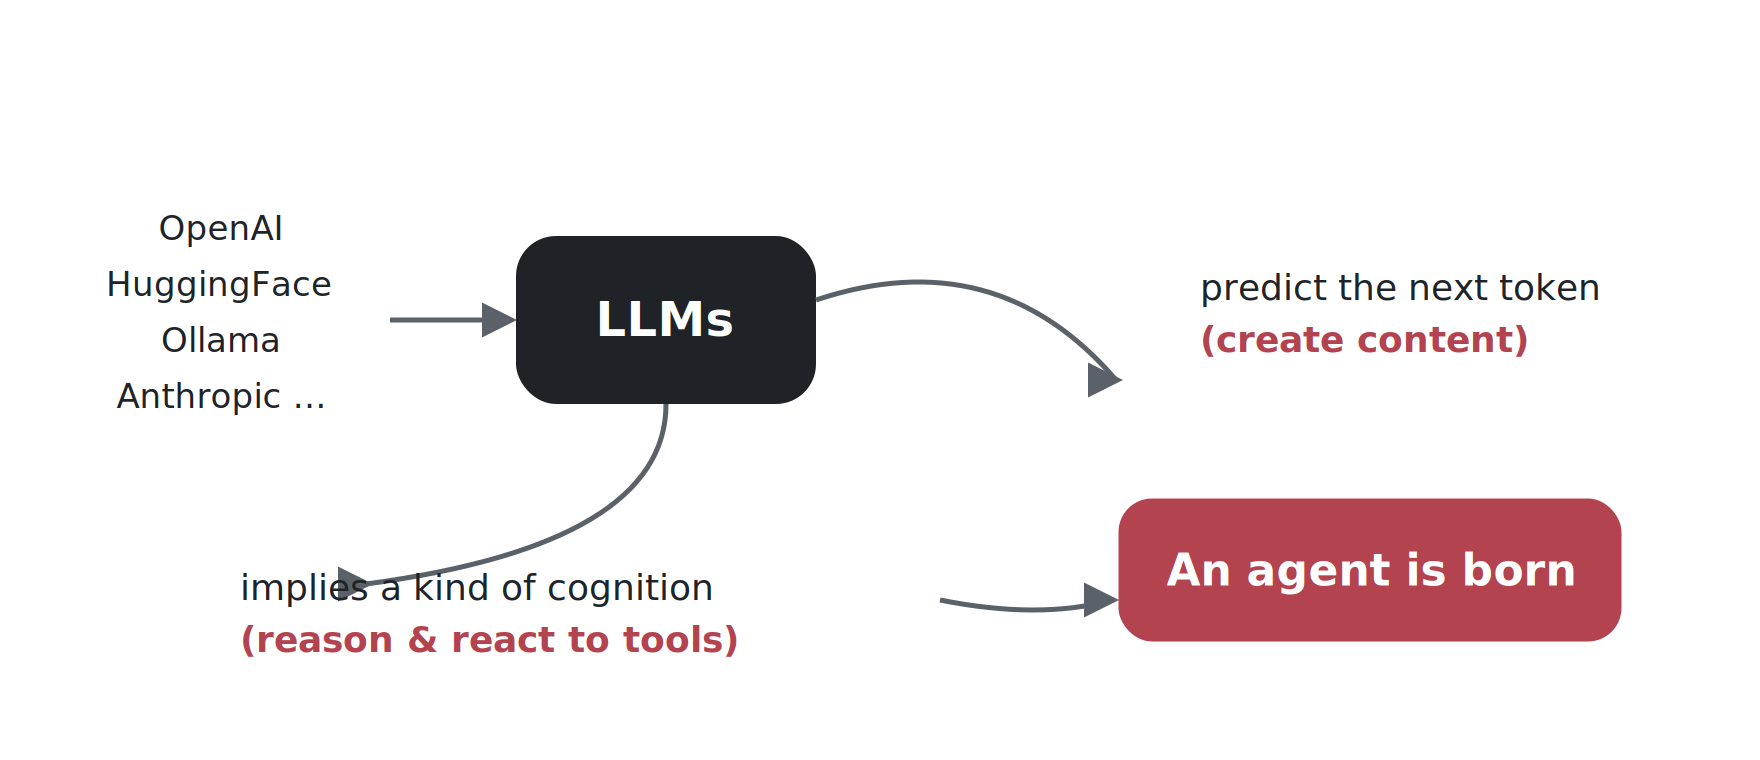

*An LLM predicts tokens; add a reason-and-react loop over tools and an agent is born.*

### The whole picture: Agent + Task + Crew

Three objects. **Agents** are role-playing workers, **Tasks** are units of work
assigned to an agent, and a **Crew** owns agents + tasks and runs them under a
**Process**.

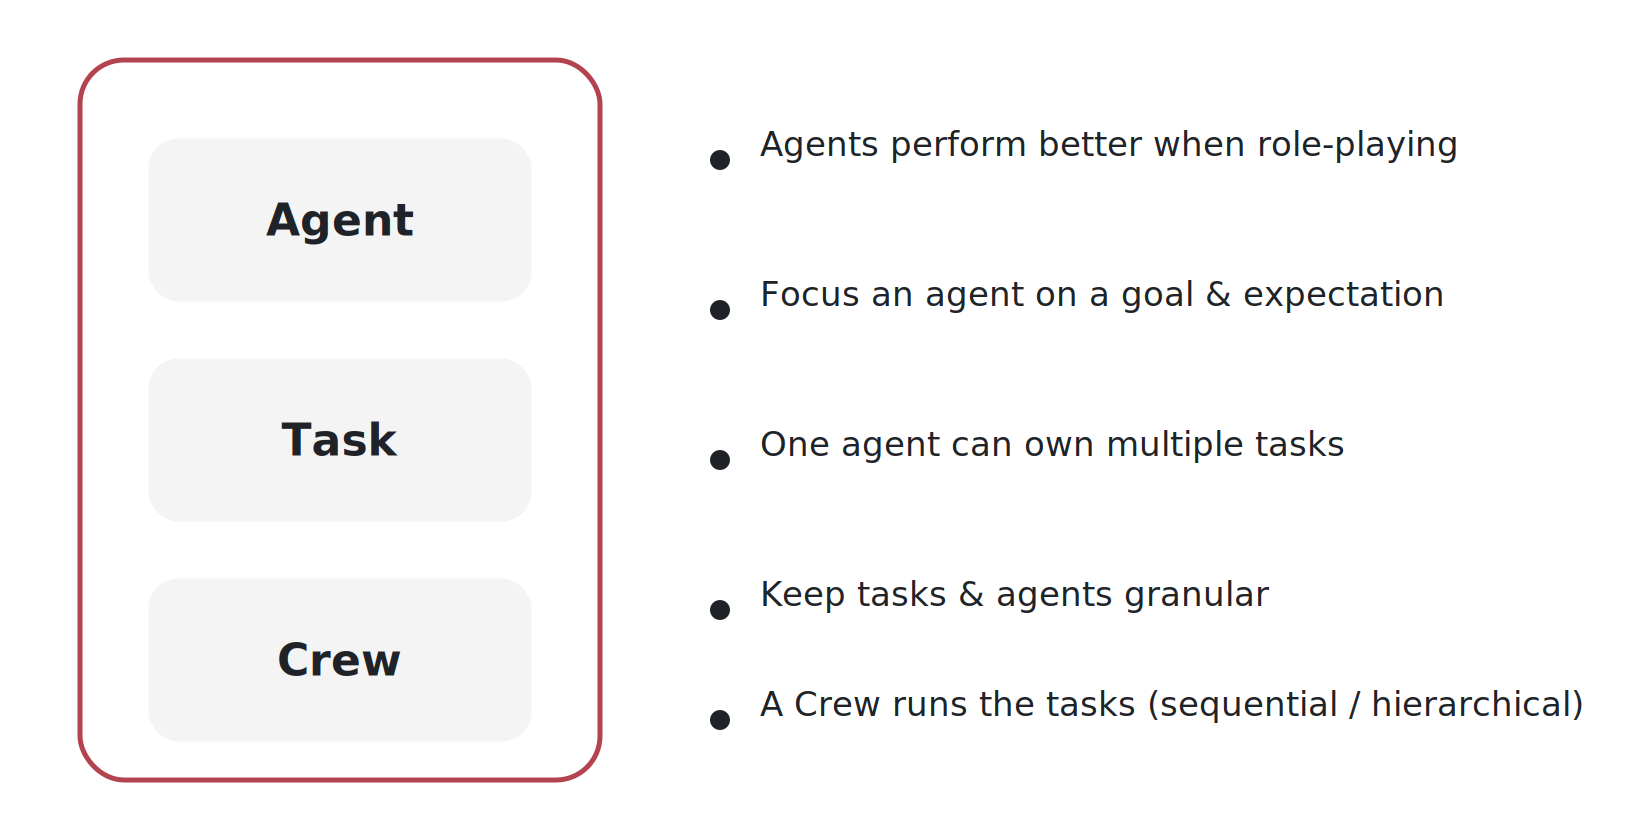

*Agent + Task + Crew — one agent can own many tasks; the Crew runs them.*

## Agents

At runtime an agent loops: reason → call a tool → observe → repeat, until it
can produce the task's answer.

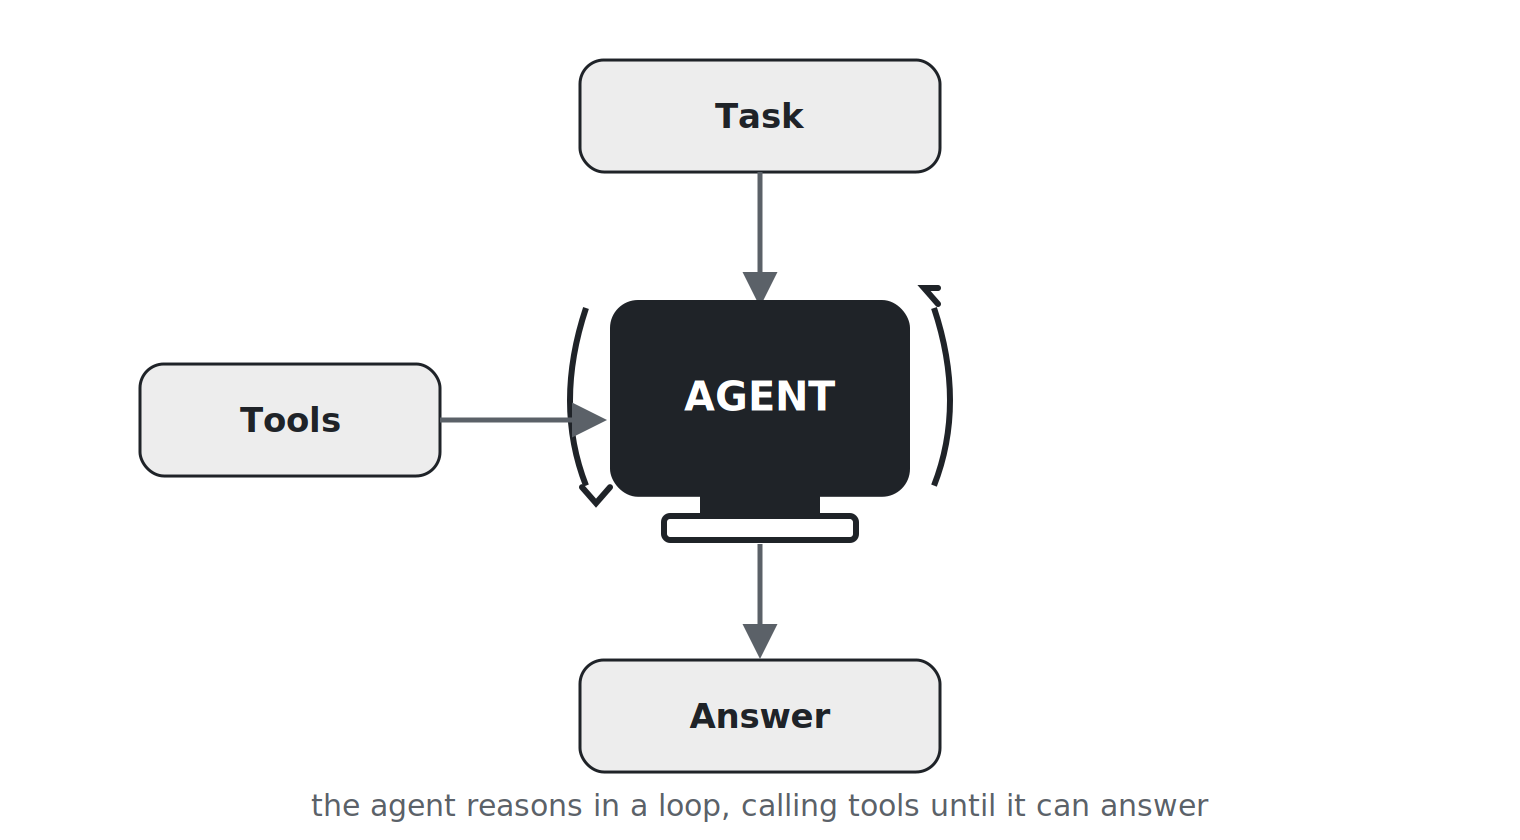

*A single agent: a Task comes in, the agent loops over its tools, an Answer comes out.*

Statically, an agent is a **persona** (3 text fields that become its system
prompt) + an **LLM** + optional **tools** + behavior flags.

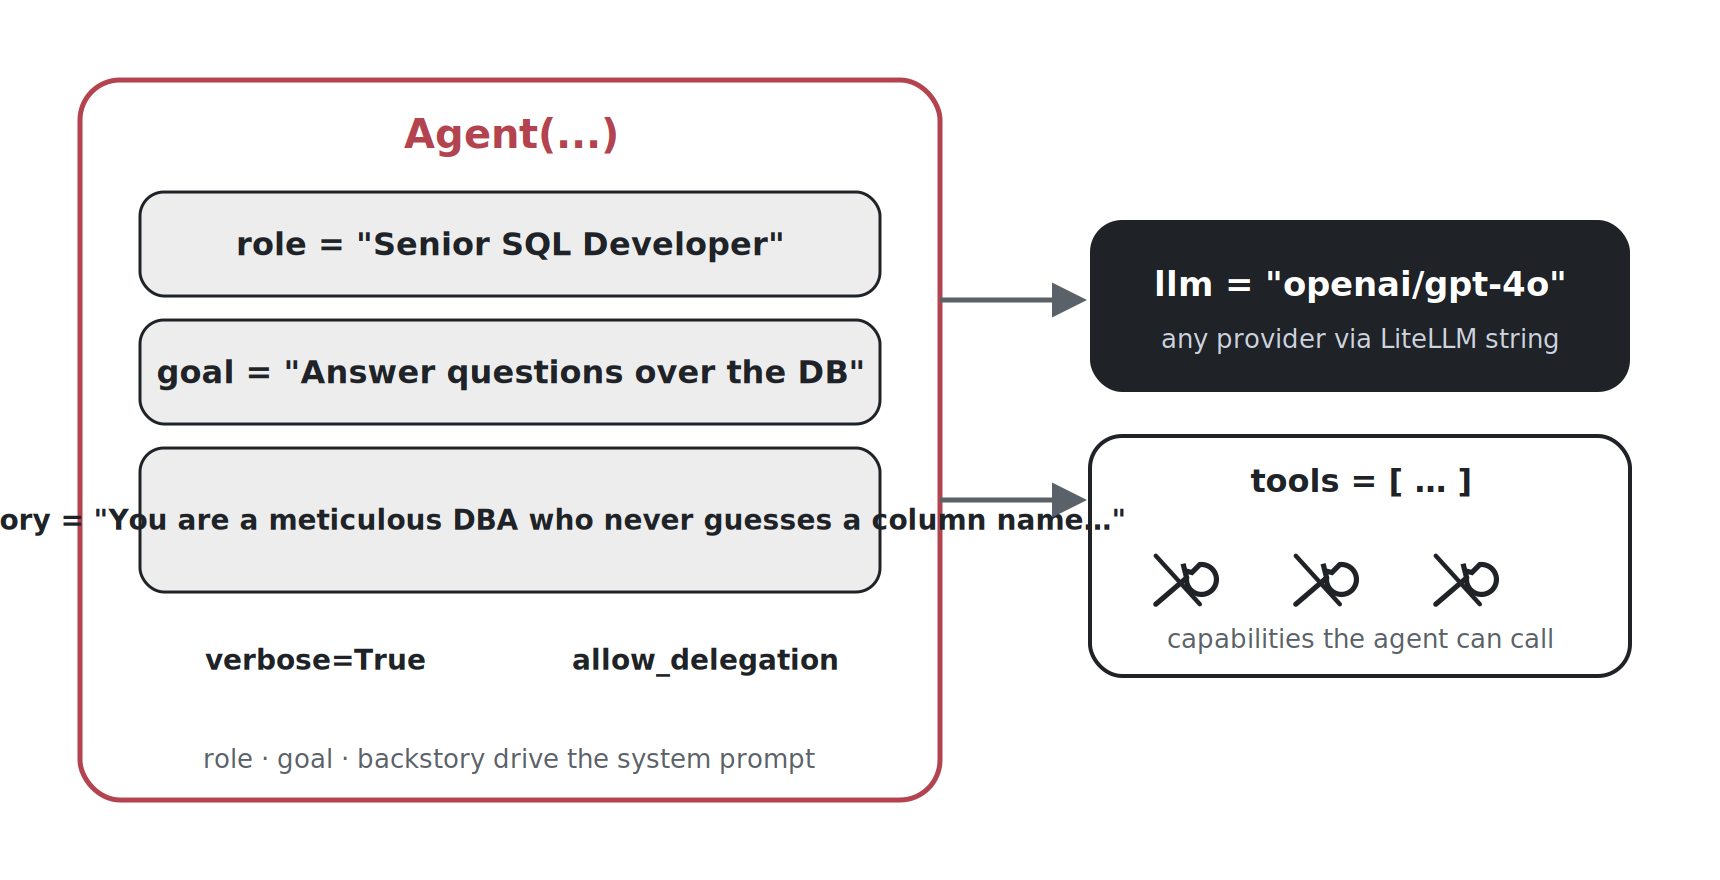

*An Agent = role + goal + backstory + an LLM + tools + behavior flags.*

The persona pattern from `L2_research_write_article.ipynb` (this is an
*illustration* — Part 2 has the runnable version):

```python
from crewai import Agent, LLM

llm = LLM(model="openai/gpt-4o-mini")          # any provider via LiteLLM string

planner = Agent(
    role="Content Planner",
    goal="Plan engaging, factually accurate content on {topic}",
    backstory=("You're planning a blog article about {topic}. You collect "
               "information that helps the audience make informed decisions. "
               "Your work is the basis for the Content Writer."),
    llm=llm, allow_delegation=False, verbose=True,
)

editor = Agent(
    role="Editor",
    goal="Edit the post to the organization's voice and journalistic norms",
    backstory="You ensure balance, avoid unsupported claims, and fix grammar.",
    llm=llm, allow_delegation=False, verbose=True,
)
```

The `"a" "b"` adjacent-string trick concatenates without the stray
newlines/indentation a triple-quoted string would inject into the prompt.

| field | what it does |
|---|---|
| `role` / `goal` / `backstory` | the persona → system prompt (use `{placeholders}`) |
| `llm` | `LLM(model="provider/model")`; omit → default OpenAI model |
| `tools` | tools this agent may call on any of its tasks |
| `allow_delegation` | if `True`, can hand work to another agent (default `True`) |
| `verbose` | print the agent's reasoning / tool calls |
| `max_iter`, `memory` | cap reasoning loops; opt into memory |

## Tasks

A Task = **description + the shape of the expected output + the owning agent**.
`expected_output` is how the agent knows it is *done*, so be specific.

```python
from crewai import Task

plan = Task(
    description=("1. Prioritise latest trends & news on {topic}.\n"
                 "2. Identify the audience and their pain points.\n"
                 "3. Produce an outline: intro, key points, CTA."),
    expected_output="A content plan: outline, audience analysis, SEO keywords.",
    agent=planner,
)
```

Task options used across L5/L7:

- `output_json=MyPydanticModel` — force a typed, structured result.
- `output_file="report.md"` — also persist the result to disk.
- `context=[task_a, task_b]` — wait for those tasks and receive their outputs.
- `async_execution=True` — overlap with later tasks.
- `human_input=True` — pause for human approval before finalising.
- `tools=[...]` — task-level tools (see *Tools* below).

```python
from pydantic import BaseModel

class VenueDetails(BaseModel):
    name: str; address: str; capacity: int; booking_status: str

venue_task = Task(
    description="Find a venue in {city} that fits {topic}.",
    expected_output="All details of the chosen venue.",
    agent=venue_coordinator,
    output_json=VenueDetails, output_file="venue.json", human_input=True,
)
```

## Crew & `kickoff`

The Crew binds agents to tasks; `kickoff(inputs=...)` interpolates every
`{placeholder}`.

```python
from crewai import Crew

crew = Crew(agents=[planner, writer, editor],
            tasks=[plan, write, edit], verbose=True)   # sequential by default
result = crew.kickoff(inputs={"topic": "Artificial Intelligence"})
```

## Six things that make agents good

`L3_customer_support.ipynb` frames the levers that turn a flaky agent reliable.

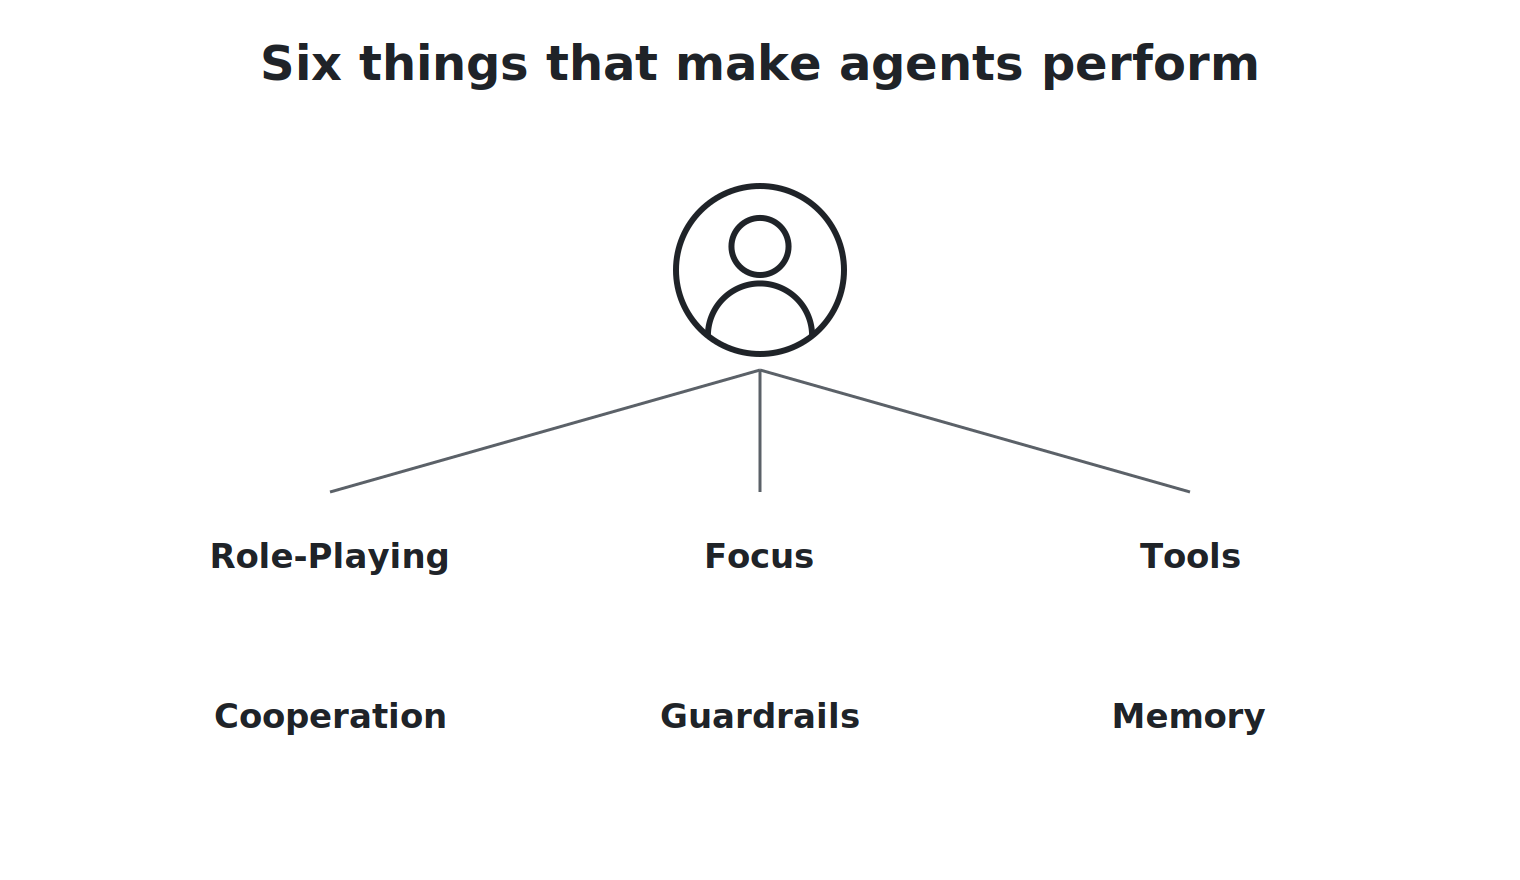

*Role-Playing · Focus · Tools · Cooperation · Guardrails · Memory.*

## Tools

A tool turns the agent's **fuzzy text** into a **typed action** against the
real world and a **typed result** back. Three properties make one good:
**versatile** (typed in/out), **fault-tolerant** (returns the error as text so
the agent can retry), and **cacheable** (identical calls memoised in a run).

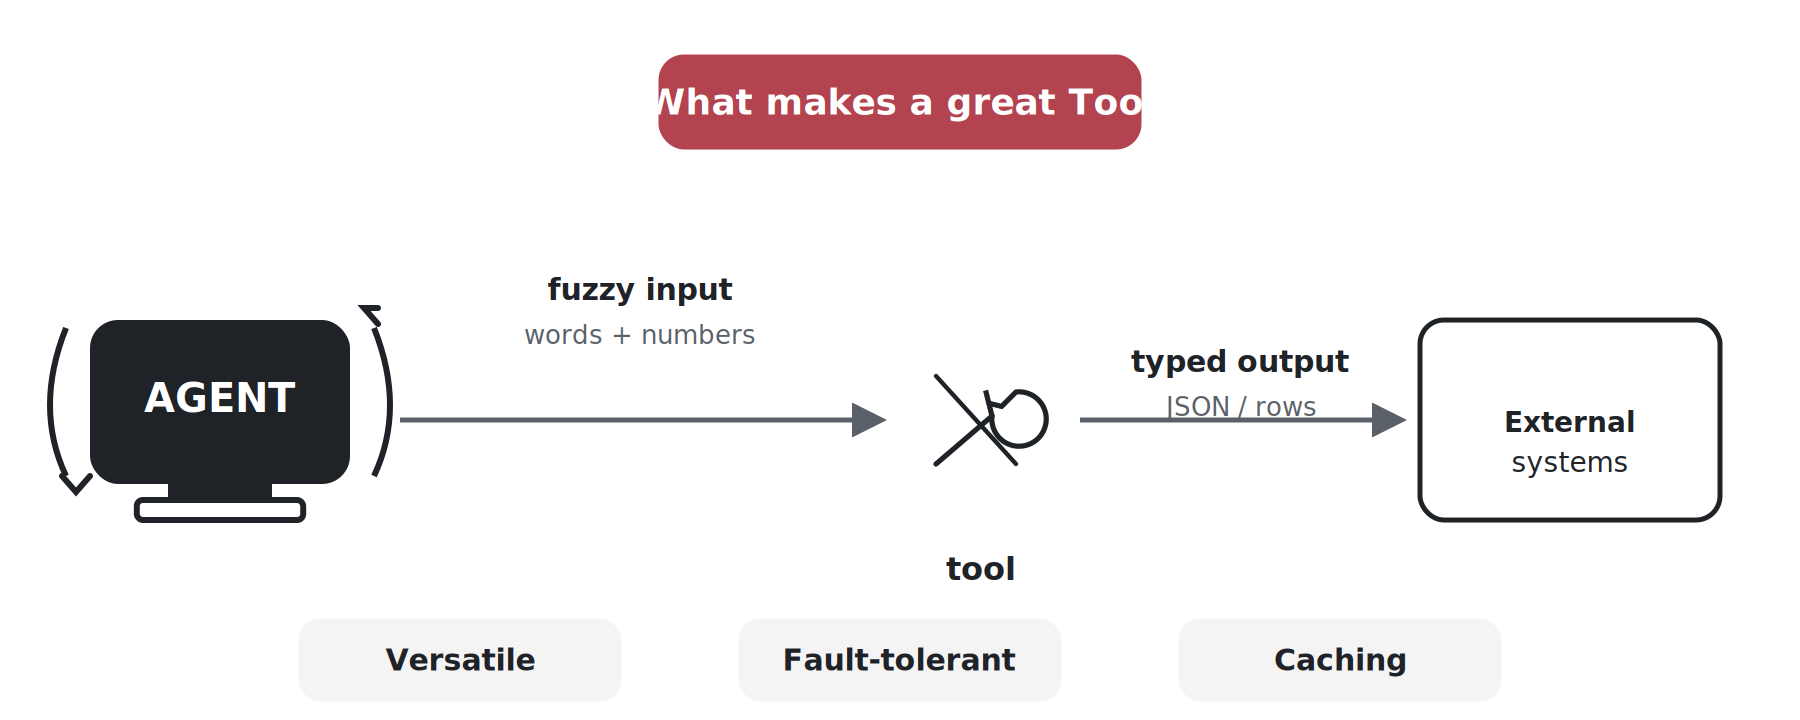

*Fuzzy text in → typed action → typed result out. Versatile · Fault-tolerant · Caching.*

**Prebuilt tools** (`crewai_tools`) — used in L4/L5/L6/L7:

```python
from crewai_tools import (SerperDevTool, ScrapeWebsiteTool,
                          DirectoryReadTool, FileReadTool, MDXSearchTool)
search = SerperDevTool()                         # web search (SERPER key)
scrape = ScrapeWebsiteTool(website_url="https://docs.crewai.com/")
rag    = MDXSearchTool(mdx="./resume.md")        # semantic search over a file
```

**Custom tool — way 1: `@tool`** (quick, function-style):

```python
from crewai.tools import tool

@tool("Sentiment Analysis Tool")
def sentiment(text: str) -> str:
    "Analyze sentiment to keep communication positive."
    return "positive"
```

**Custom tool — way 2: subclass `BaseTool`** (preferred — gives a typed
`args_schema`, i.e. the *versatile* pillar). You will **build and run** this in
Part 3.

**Where tools live:** agent-level tools work on any of that agent's tasks;
task-level tools apply only to that task **and override the agent's tools for
it** (L3 & L4 rely on this).

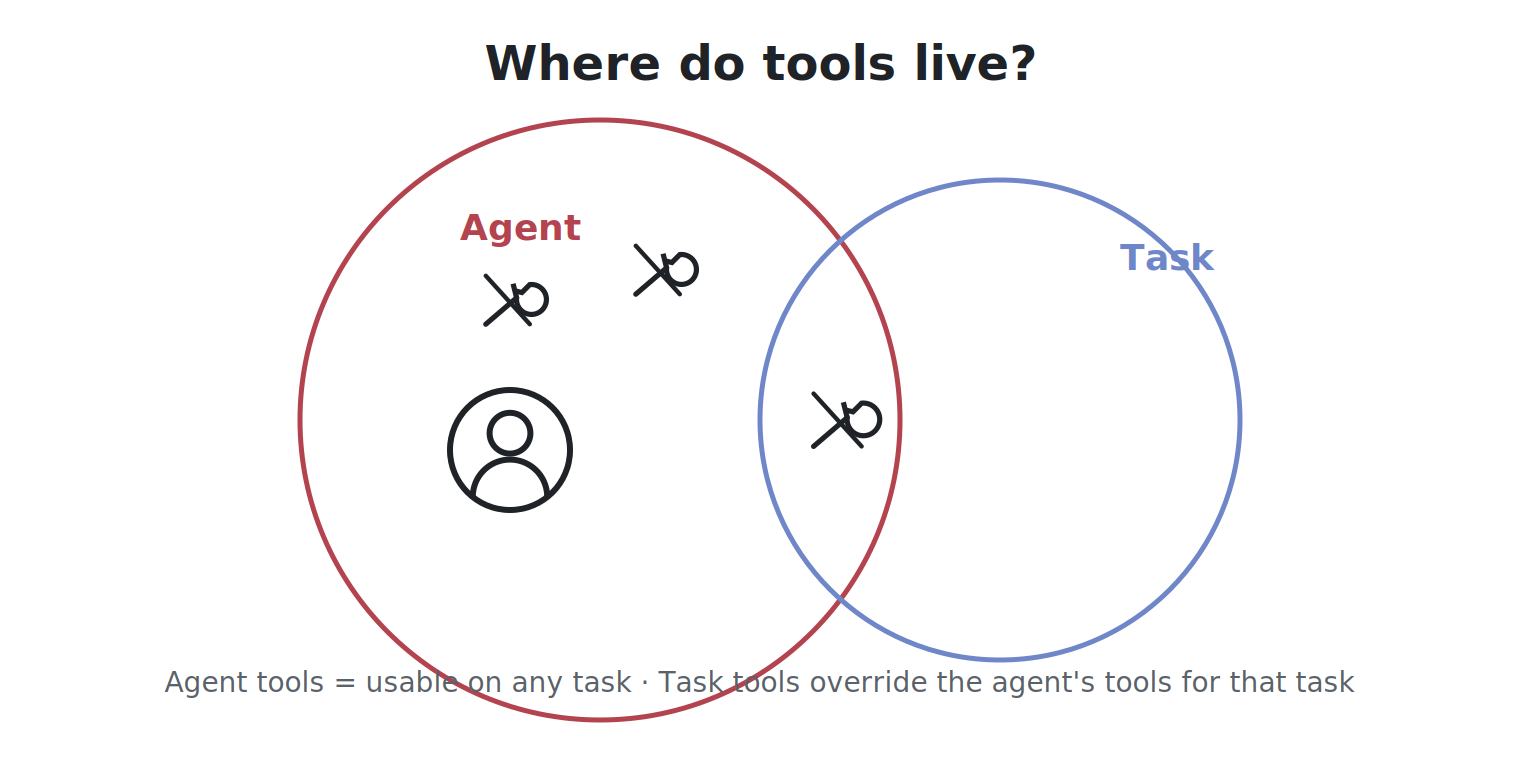

*Agent tools vs Task tools — task tools win for that task.*

## Memory

`memory=True` on the Crew (L3/L4) enables **short-term** (within a run),
**long-term** (across runs — "remember & learn"), and **entity** memory
(people/orgs/places).

```python
crew = Crew(agents=[support, qa], tasks=[resolve, review], memory=True)
```

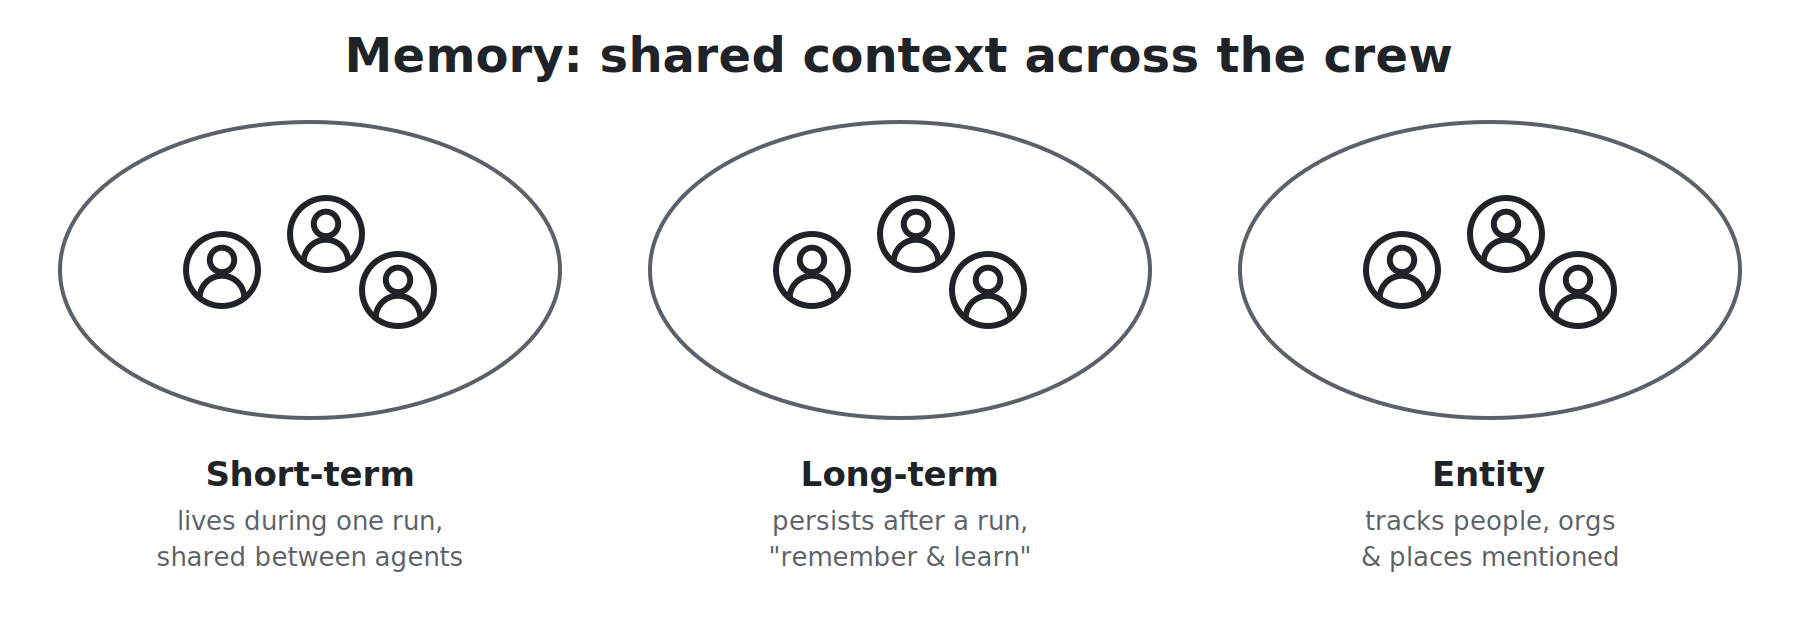

*Short-term (this run), Long-term (across runs), Entity (who/what/where).*

## Delegation & collaboration

`allow_delegation=True` lets an agent hand work to a better-suited agent or
hand it back for revision (L3's Support + QA pattern).

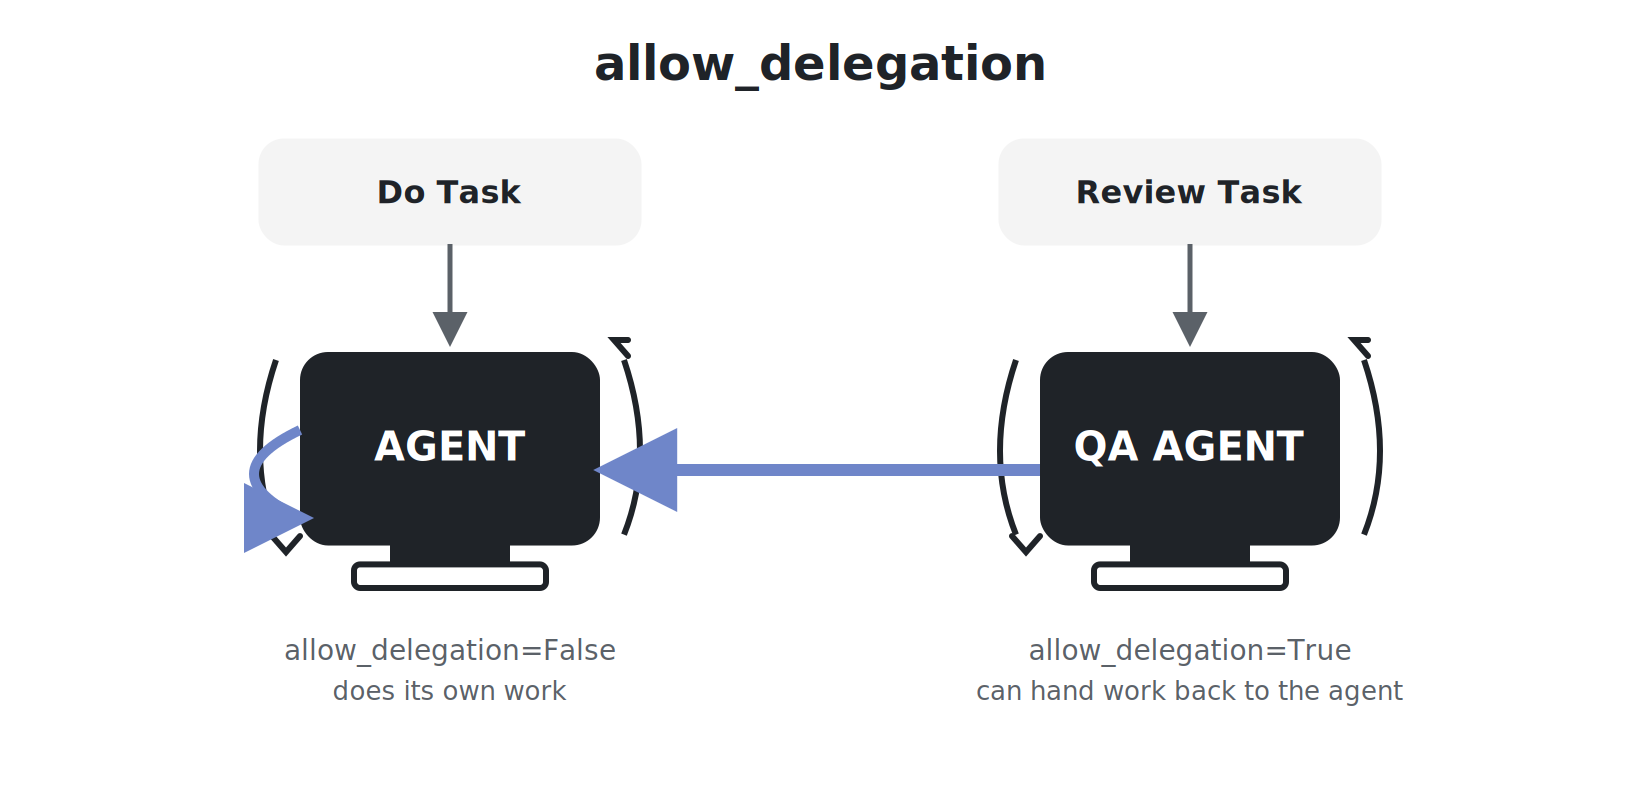

*QA agent can delegate back; the doer just does its own work.*

## Processes: sequential vs hierarchical

**Sequential** (default) runs tasks in list order. **Hierarchical** (L6) adds a
**manager LLM** that plans, delegates, and validates each step.

```python
from crewai import Crew, Process
crew = Crew(agents=[...], tasks=[...], process=Process.hierarchical,
            manager_llm=LLM(model="openai/gpt-4o", temperature=0.7))
```

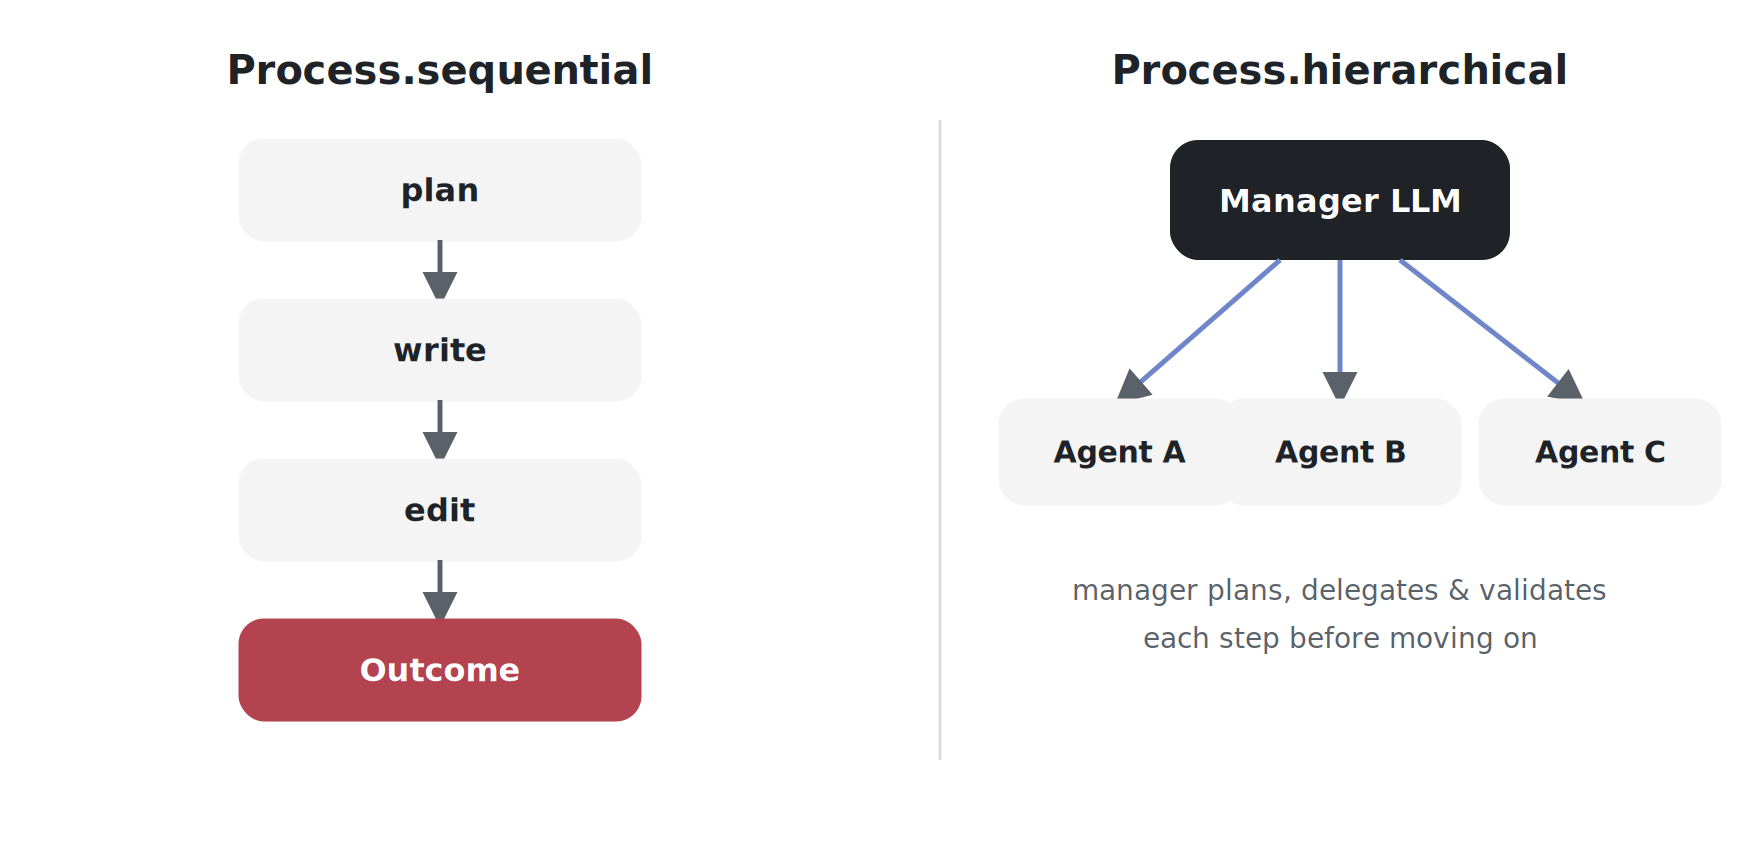

*Sequential = ordered chain. Hierarchical = a manager LLM delegates & checks.*

### The full lifecycle

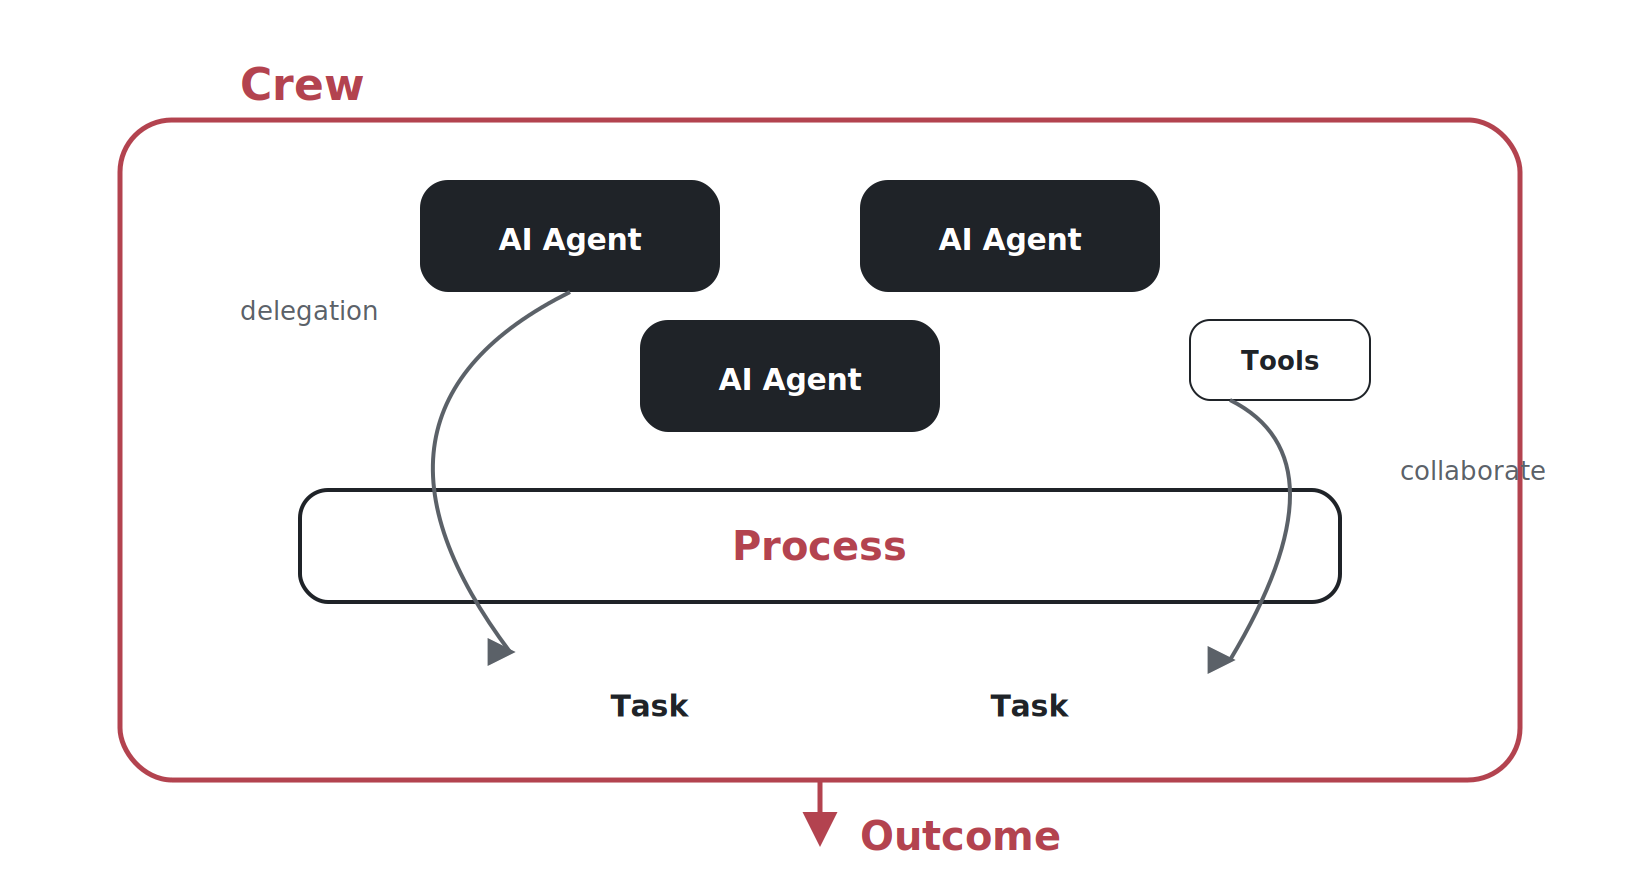

*Crew { agents + process + tasks } → outcome. Task tools override agent tools.*

### A framework is not reliability

CrewAI gives you the *objects*; **reliability is something you engineer**. The
levers, and where this tutorial uses each one:

| Reliability lever | Where Part 4 uses it |
|---|---|
| Narrow role | `Weather Researcher`, `Senior Database Analyst` |
| Tool contract | Pydantic `args_schema` on every tool |
| Error recovery | SQL error returned to the agent as text → it retries |
| Guardrail | `SELECT`/`WITH` only, single statement, read-only DB connection |
| Determinism | `temperature=0` on the LLM |
| Schema grounding | `list_tables` + `describe_table` before any SQL |
| Method, not vibes | the agent's procedure is fixed in its `backstory` |

### Quick check

<details><summary><b>Q1.</b> Tasks in a default Crew run (a) parallel
(b) list order (c) random (d) by priority</summary>

**(b)** — `Process.sequential` is default; the `tasks` order matters. Use
`async_execution=True` to overlap specific tasks.</details>

<details><summary><b>Q2.</b> Task sets <code>tools=[X]</code>, its agent has
<code>tools=[Y,Z]</code>. During that task the agent can use…</summary>

**Only `X`.** Task tools override the agent's tools for that task.</details>

<details><summary><b>Q3.</b> Why subclass <code>BaseTool</code> over
<code>@tool</code> for production?</summary>

A typed Pydantic `args_schema` (versatile) plus a clean place to catch errors
and return them as text (fault-tolerant).</details>

<details><summary><b>Q4.</b> Which Crew flag gives cross-run "remember &
learn"?</summary>

**`memory=True`** on the `Crew`.</details>

# Part 2 — A tiny runnable Crew

The smallest real thing: **one agent, one task, `kickoff`**. The cell is
guarded by `run_crew` — with a key it runs for real; without one it prints the
expected output, so *Run All* stays green.

In [ ]:
from crewai import Agent, Task, Crew, LLM

llm = LLM(model=CREWAI_MODEL, temperature=0)

haiku_bot = Agent(
    role="Haiku Poet",
    goal="Write a single vivid haiku about {topic}",
    backstory="You write tight 5-7-5 imagery and nothing else.",
    llm=llm, allow_delegation=False, verbose=True,
)

haiku_task = Task(
    description="Write ONE haiku about {topic}. Output only the haiku.",
    expected_output="Three lines, 5-7-5 syllables, about {topic}.",
    agent=haiku_bot,
)

tiny_crew = Crew(agents=[haiku_bot], tasks=[haiku_task], verbose=True)

result = run_crew(
    tiny_crew, {"topic": "autumn rain"},
    expected="autumn rain whispers / cold drops trace the windowpane / "
             "leaves let go and fall",
)
print(result if result else "(printed expected output above)")

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: dc74de73-5195-473b-b759-cfe419eecb2b                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Haiku Poet                                                                                              │
│                                                                                                                 │
│  Task: Write ONE haiku about autumn rain. Output only the haiku.                                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Haiku Poet                                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Whispers of the sky,                                                                                           │
│  Crisp leaves dance in silver drops,                                                                            │
│  Autumn's soft embrace.                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Task Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: beb9f41c-883c-4a1e-8f0e-8b2f7474b990                                                                     │
│  Agent: Haiku Poet                                                                                              │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: dc74de73-5195-473b-b759-cfe419eecb2b                                                                       │
│  Tool Args:                                                                                                     │
│  Final Output: Whispers of the sky,                                                                             │
│  Crisp leaves dance in silver drops,                                                                            │
│  Autumn's soft embrace.                                                                                         │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── Execution Traces ────────────────────────────────────────────────╮
│                                                                                                                 │
│  🔍 Detailed execution traces are available!                                                                    │
│                                                                                                                 │
│  View insights including:                                                                                       │
│    • Agent decision-making process                                                                              │
│    • Task execution flow and timing                                                                             │
│    • Tool usage details                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Would you like to view your execution traces? [y/N] (20s timeout): y


╭───────────────────────────────────────── 🔍 Execution Trace Generated ──────────────────────────────────────────╮
│                                                                                                                 │
│  🎉 Your First CrewAI Execution Trace is Ready!                                                                 │
│                                                                                                                 │
│  View your execution details here:                                                                              │
│  https://app.crewai.com/crewai_plus/ephemeral_trace_batches/6c3be8ef-c626-4e53-a891-7315603e8a5a?access_code=T  │
│  RACE-fbe34d0864                                                                                                │
│                                                                                                                 │
│  This trace shows:                                                                                              │
│  • Agent decisions and interactions                                                                             │
│  • Task execution timeline                                                                                      │
│  • Tool usage and results                                                                                       │
│  • LLM calls and responses                                                                                      │
│                                                                                                                 │
│  ✅ Tracing has been enabled for future runs! (CREWAI_TRACING_ENABLED=true added to .env)                       │
│  You can also add tracing=True to your Crew(tracing=True) / Flow(tracing=True) for more control.                │
│                                                                                                                 │
│  📝 Note: This link will expire in 24 hours.                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Whispers of the sky,  
Crisp leaves dance in silver drops,  
Autumn's soft embrace.


# Part 3 — A tool-using agent (and how to read its loop)

We define a **real `BaseTool`** and call it **directly** — this runs with no
API key — then wire it to an agent.

In [ ]:
from typing import Type
from pydantic import BaseModel, Field
try:
    from crewai.tools import BaseTool          # crewai >= 0.51
except ImportError:                            # older crewai
    from crewai_tools import BaseTool

class WordStatsInput(BaseModel):
    text: str = Field(..., description="The text to analyze.")

class WordStatsTool(BaseTool):
    name: str = "word_stats"
    description: str = "Return word count and the longest word in some text."
    args_schema: Type[BaseModel] = WordStatsInput

    def _run(self, text: str) -> str:
        words = text.split()
        if not words:
            return "ERROR: empty text."        # fault-tolerant: no exception
        longest = max(words, key=len)
        return f"words={len(words)}; longest='{longest}' ({len(longest)} chars)"

# RUNS with no LLM / no key — a tool is just a typed function:
print(WordStatsTool()._run("CrewAI turns an LLM into a reliable agent"))
print(WordStatsTool()._run(""))               # fault tolerance in action

words=8; longest='reliable' (8 chars)
ERROR: empty text.


Now hand the tool to an agent. Guarded, so it's safe to *Run All*.

In [ ]:
analyst = Agent(
    role="Text Analyst",
    goal="Answer questions about a text using your tool, never by guessing.",
    backstory="You always call word_stats and report exactly what it returns.",
    tools=[WordStatsTool()], llm=llm, allow_delegation=False, verbose=True,
)
analysis_task = Task(
    description="Use your tool on this text: '{text}'. Report the stats.",
    expected_output="The word count and the longest word.",
    agent=analyst,
)
crew3 = Crew(agents=[analyst], tasks=[analysis_task], verbose=True)

run_crew(crew3, {"text": "agents reason then act then observe then repeat"},
         expected="words=8; longest='observe' (7 chars)")

╭──────────────────────────────────────────── Crew Execution Started ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: ab635b9c-9a2f-4f74-8406-ddbd3f6e1c26                                                                       │
│  Tool Args:                                                                                                     │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Text Analyst                                                                                            │
│                                                                                                                 │
│  Task: Use your tool on this text: 'agents reason then act then observe then repeat'. Report the stats.         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Output()

╭──────────────────────────────────────────── 🔧 Agent Tool Execution ────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Text Analyst                                                                                            │
│                                                                                                                 │
│  Thought: Thought: I need to analyze the provided text to get the word count and the longest word.              │
│                                                                                                                 │
│  Using Tool: word_stats                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────────── Tool Input ───────────────────────────────────────────────────╮
│                                                                                                                 │
│  {                                                                                                              │
│    "text": "agents reason then act then observe then repeat"                                                    │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭─────────────────────────────────────────────── Execution Traces ────────────────────────────────────────────────╮
│                                                                                                                 │
│  🔍 Detailed execution traces are available!                                                                    │
│                                                                                                                 │
│  View insights including:                                                                                       │
│    • Agent decision-making process                                                                              │
│    • Task execution flow and timing                                                                             │
│    • Tool usage details                                                                                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Would you like to view your execution traces? [y/N] (20s timeout): y


╭─────────────────────────────────────────── Trace Batch Finalization ────────────────────────────────────────────╮
│ ✅ Trace batch finalized with session ID: abc8852e-4a2f-4d91-854e-bd86873e436e                                  │
│                                                                                                                 │
│ 🔗 View here:                                                                                                   │
│ https://app.crewai.com/crewai_plus/ephemeral_trace_batches/abc8852e-4a2f-4d91-854e-bd86873e436e?access_code=TRA │
│ CE-c12ff24a0f                                                                                                   │
│ 🔑 Access Code: TRACE-c12ff24a0f                                                                                │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────── 🔍 Execution Trace Generated ──────────────────────────────────────────╮
│                                                                                                                 │
│  🎉 Your First CrewAI Execution Trace is Ready!                                                                 │
│                                                                                                                 │
│  View your execution details here:                                                                              │
│  https://app.crewai.com/crewai_plus/ephemeral_trace_batches/abc8852e-4a2f-4d91-854e-bd86873e436e?access_code=T  │
│  RACE-c12ff24a0f                                                                                                │
│                                                                                                                 │
│  This trace shows:                                                                                              │
│  • Agent decisions and interactions                                                                             │
│  • Task execution timeline                                                                                      │
│  • Tool usage and results                                                                                       │
│  • LLM calls and responses                                                                                      │
│                                                                                                                 │
│  ✅ Tracing has been enabled for future runs! (CREWAI_TRACING_ENABLED=true added to .env)                       │
│  You can also add tracing=True to your Crew(tracing=True) / Flow(tracing=True) for more control.                │
│                                                                                                                 │
│  📝 Note: This link will expire in 24 hours.                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CrewOutput(raw="words=8; longest='observe' (7 chars)", pydantic=None, json_dict=None, tasks_output=[TaskOutput(description="Use your tool on this text: 'agents reason then act then observe then repeat'. Report the stats.", name="Use your tool on this text: 'agents reason then act then observe then repeat'. Report the stats.", expected_output='The word count and the longest word.', summary="Use your tool on this text: 'agents reason then act...", raw="words=8; longest='observe' (7 chars)", pydantic=None, json_dict=None, agent='Text Analyst', output_format=<OutputFormat.RAW: 'raw'>)], token_usage=UsageMetrics(total_tokens=757, prompt_tokens=689, cached_prompt_tokens=0, completion_tokens=68, successful_requests=2))

### Reading the CrewAI trace

With `verbose=True` you see the agent's loop. It looks like this (annotated):

```text
# Agent: Text Analyst
## Task: Use your tool on this text: 'agents reason ...'

# Agent: Text Analyst
## Thought: I should call word_stats with the given text.        <- reasons
## Using tool: word_stats                                         <- acts
## Tool Input: {"text": "agents reason then act ..."}             <- typed input
## Tool Output: words=8; longest='observe' (7 chars)              <- observes

# Agent: Text Analyst
## Final Answer: The text has 8 words; the longest is 'observe'.  <- answers
```

The four beats — **Thought -> Tool call -> Observation -> Final Answer** — are
the agent loop. On a tool error the Observation contains the error string and
the agent emits another Thought -> Tool call (a *retry*). You will see exactly
this, multiple times, in the Text-to-SQL agent in Part 4.

# Part 4 — Local project: weather + Text-to-SQL (built here, run with `uv`)

Two agents, two kinds of tools:

1. **Weather Researcher** -> a CrewAI tool on the free, key-less **Open-Meteo**
   API (real-time).
2. **Senior Database Analyst** -> three **user-defined** CrewAI tools doing
   **Text-to-SQL** over local SQLite.

The SQL tools are a faithful port of the LangChain `@tool` functions
(`list_tables_tool` / `get_table_schema_tool` / `execute_sql_tool`) from the
`react_text2sql` notebook — MySQL -> SQLite, wrapped as CrewAI `BaseTool`s.

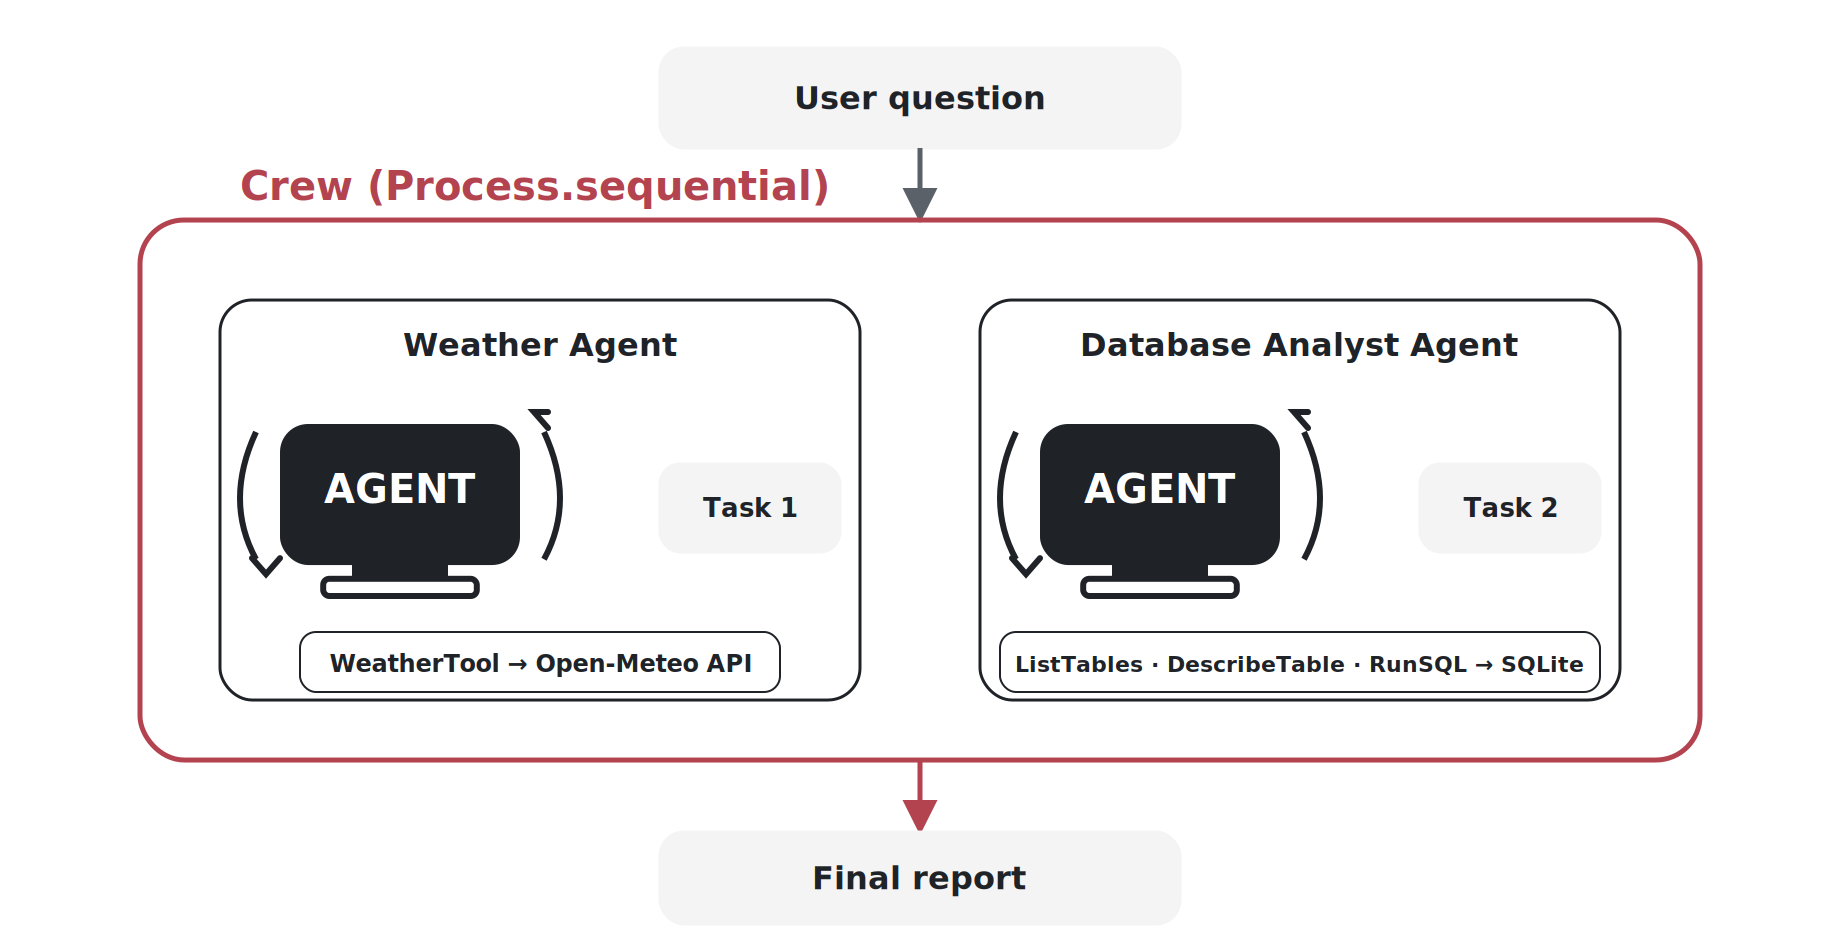

*User question -> sequential Crew -> Weather agent + DBA agent -> final report.*

The Database Analyst reasons step by step. On a SQL error the tool returns the
message and the agent retries — the *fault-tolerance* pillar, live:

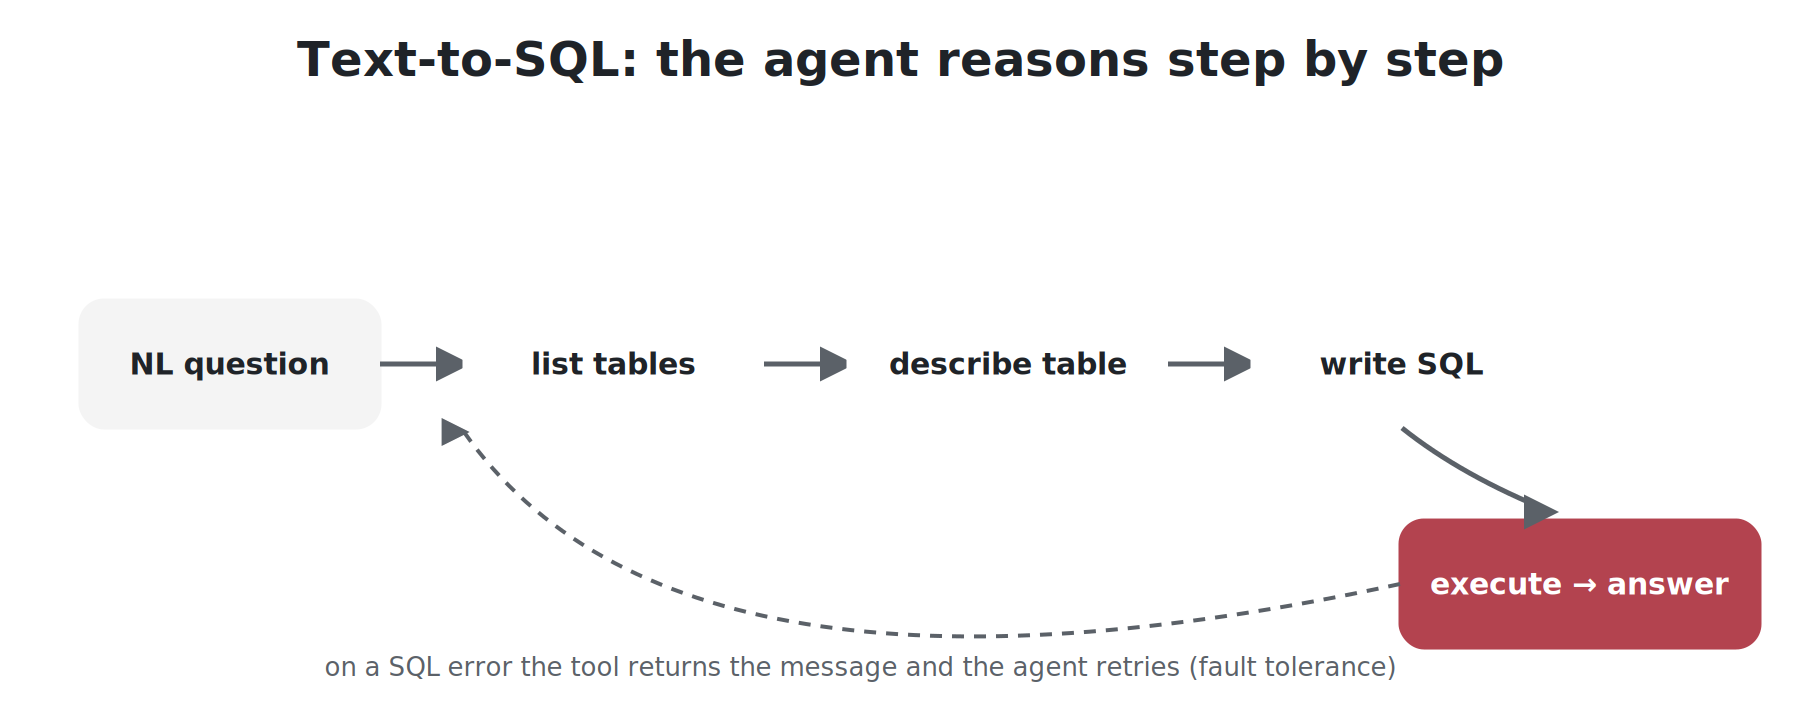

*list tables -> describe table -> write SQL -> execute. SQL errors loop back to retry.*

### Write the repo (these `%%writefile` cells create real files on disk)

We create the directory tree first (`%%writefile` will not create parents),
then write **complete, verified** files — no abridged fragments.

In [ ]:
import os, pathlib
for d in ("crewai_text2sql/src/crew_sql", "crewai_text2sql/scripts",
          "crewai_text2sql/tests", "crewai_text2sql/data"):
    pathlib.Path(d).mkdir(parents=True, exist_ok=True)
os.chdir("crewai_text2sql")
print("repo root:", pathlib.Path.cwd())

In [ ]:
%%writefile pyproject.toml
[project]
name = "crewai-text2sql"
version = "0.1.0"
description = "A CrewAI multi-agent system: a real-time Weather agent + a Text-to-SQL agent over SQLite, fully runnable with uv."
readme = "README.md"
requires-python = ">=3.11,<3.14"

# Pinned for reproducibility. CrewAI moves fast; these ranges are known-good.
dependencies = [
    "crewai>=0.130,<1.0",
    "requests>=2.32",
    "python-dotenv>=1.0",
]

[project.scripts]
# `uv run text2sql "<question>"`  is wired to main:main
text2sql = "main:main"

[tool.uv]
# keep the resolver fast & deterministic
package = false

[build-system]
requires = ["hatchling"]
build-backend = "hatchling.build"


In [ ]:
%%writefile .env.example
# ---------------------------------------------------------------------------
# Pick ONE backend for the agents' LLM. CrewAI uses LiteLLM under the hood,
# so the MODEL string is "<provider>/<model>".
# ---------------------------------------------------------------------------

# Option A — OpenAI (simplest; needs a key)
CREWAI_MODEL=openai/gpt-4o-mini
OPENAI_API_KEY=sk-your-key-here

# Option B — Anthropic
# CREWAI_MODEL=anthropic/claude-sonnet-4-6
# ANTHROPIC_API_KEY=sk-ant-your-key-here

# Option C — fully local, no key, mirrors the original HF notebook.
#   1) install ollama   2) `ollama pull llama3.1`   3) uncomment below
# CREWAI_MODEL=ollama/llama3.1
# OPENAI_API_KEY=                     # leave empty for local

# Path to the SQLite file the Text-to-SQL agent queries (auto-created).
TEXT2SQL_DB=data/shop.db


In [ ]:
%%writefile src/crew_sql/__init__.py
"""crew_sql — a CrewAI weather + text-to-SQL multi-agent system."""
__all__ = ["build_crew", "build_agents"]


In [ ]:
%%writefile src/crew_sql/db.py
"""
Builds a tiny, deterministic SQLite database so the Text-to-SQL agent has
something real to query.

The schema deliberately mirrors the BIRD `debit_card_specializing` slice used
in the original LangGraph notebook, so the canonical demo question still works:

    "What is the ratio of customers who pay in EUR against customers who pay in CZK?"

Seeded so the answer is exactly 2.0  (60 EUR customers / 30 CZK customers).
"""
from __future__ import annotations

import os
import sqlite3
from pathlib import Path

DB_PATH = Path(os.getenv("TEXT2SQL_DB", "data/shop.db"))

_SCHEMA = """
CREATE TABLE customers (
    CustomerID INTEGER PRIMARY KEY,
    Segment    TEXT NOT NULL,          -- 'SME' | 'LAM' | 'KAM'
    Currency   TEXT NOT NULL           -- 'EUR' | 'CZK' | 'USD'
);

CREATE TABLE products (
    ProductID   INTEGER PRIMARY KEY,
    Description TEXT NOT NULL,
    UnitPrice   REAL NOT NULL
);

CREATE TABLE transactions (
    TransactionID INTEGER PRIMARY KEY,
    Date          TEXT NOT NULL,        -- ISO 'YYYY-MM-DD'
    CustomerID    INTEGER NOT NULL,
    ProductID     INTEGER NOT NULL,
    Amount        REAL NOT NULL,
    FOREIGN KEY (CustomerID) REFERENCES customers (CustomerID),
    FOREIGN KEY (ProductID)  REFERENCES products  (ProductID)
);
"""

_PRODUCTS = [
    (1, "Diesel",         1.62),
    (2, "Unleaded 95",    1.71),
    (3, "Unleaded 98",    1.83),
    (4, "Car Wash",       9.00),
    (5, "Premium Coffee", 2.40),
]


def _customers() -> list[tuple[int, str, str]]:
    rows: list[tuple[int, str, str]] = []
    cid = 1
    # 60 EUR, 30 CZK, 10 USD  ->  EUR : CZK ratio = 2.0
    for currency, n in (("EUR", 60), ("CZK", 30), ("USD", 10)):
        for i in range(n):
            segment = ("SME", "LAM", "KAM")[i % 3]
            rows.append((cid, segment, currency))
            cid += 1
    return rows


def _transactions(customers: list[tuple[int, str, str]]) -> list[tuple]:
    rows: list[tuple] = []
    tid = 1
    for cust_id, _seg, _cur in customers:
        # each customer makes 3 deterministic transactions
        for k in range(3):
            product_id = (cust_id + k) % len(_PRODUCTS) + 1
            unit_price = _PRODUCTS[product_id - 1][2]
            qty = (cust_id + k) % 5 + 1
            day = (cust_id + k) % 28 + 1
            rows.append(
                (tid, f"2024-0{(k % 9) + 1}-{day:02d}", cust_id,
                 product_id, round(unit_price * qty, 2))
            )
            tid += 1
    return rows


def build(force: bool = False) -> Path:
    """Create + seed the DB. Idempotent; pass force=True to rebuild."""
    DB_PATH.parent.mkdir(parents=True, exist_ok=True)
    if DB_PATH.exists() and not force:
        return DB_PATH
    if DB_PATH.exists():
        DB_PATH.unlink()

    conn = sqlite3.connect(DB_PATH)
    try:
        conn.executescript(_SCHEMA)
        custs = _customers()
        conn.executemany("INSERT INTO customers VALUES (?,?,?)", custs)
        conn.executemany("INSERT INTO products  VALUES (?,?,?)", _PRODUCTS)
        conn.executemany(
            "INSERT INTO transactions VALUES (?,?,?,?,?)", _transactions(custs)
        )
        conn.commit()
    finally:
        conn.close()
    return DB_PATH


def ensure_db() -> Path:
    """Called by tools/agents so `uv run` works with zero manual setup."""
    return build(force=False)


if __name__ == "__main__":
    path = build(force=True)
    print(f"Rebuilt {path.resolve()}")
    with sqlite3.connect(path) as c:
        for tbl in ("customers", "products", "transactions"):
            (n,) = c.execute(f"SELECT COUNT(*) FROM {tbl}").fetchone()
            print(f"  {tbl:<13} {n:>4} rows")


In [ ]:
%%writefile src/crew_sql/tools.py
"""
User-defined CrewAI tools.

Two families of tools, mapping straight onto the slide deck's three pillars
of "what makes a great tool":

  * Versatile      -> typed pydantic args_schema (fuzzy LLM text in, typed out)
  * Fault-tolerant -> SQL errors are caught and returned as text so the agent
                      can read the message and retry, instead of crashing
  * Caching        -> CrewAI memoises identical tool calls within a run

The three SQL tools are direct ports of the LangChain `@tool` functions in the
original `react_text2sql` notebook (list_tables / get_table_schema /
execute_sql), swapped from MySQL to a zero-setup local SQLite file.
"""
from __future__ import annotations

import sqlite3
from typing import Type

import requests
from pydantic import BaseModel, Field

# crewai renamed the tool base a few times; support both layouts.
try:
    from crewai.tools import BaseTool          # crewai >= 0.51
except ImportError:                            # pragma: no cover
    from crewai_tools import BaseTool          # older crewai

from crew_sql.db import ensure_db


# ===========================================================================
#  Tool 1 — list every table  (port of list_tables_tool)
# ===========================================================================
class _NoArgs(BaseModel):
    pass


class ListTablesTool(BaseTool):
    name: str = "list_tables"
    description: str = (
        "List every table in the database. "
        "Always call this FIRST so you know what tables exist."
    )
    args_schema: Type[BaseModel] = _NoArgs

    def _run(self) -> str:
        db = ensure_db()
        with sqlite3.connect(db) as conn:
            rows = conn.execute(
                "SELECT name FROM sqlite_master "
                "WHERE type='table' ORDER BY name"
            ).fetchall()
        tables = [r[0] for r in rows]
        return "Tables: " + ", ".join(tables) if tables else "No tables found."


# ===========================================================================
#  Tool 2 — describe a table  (port of get_table_schema_tool)
# ===========================================================================
class _DescribeArgs(BaseModel):
    table_name: str = Field(..., description="Exact table name to inspect.")


class DescribeTableTool(BaseTool):
    name: str = "describe_table"
    description: str = (
        "Return the column names and types for ONE table. "
        "Call this before writing SQL so you never guess a column name."
    )
    args_schema: Type[BaseModel] = _DescribeArgs

    def _run(self, table_name: str) -> str:
        db = ensure_db()
        with sqlite3.connect(db) as conn:
            valid = {
                r[0]
                for r in conn.execute(
                    "SELECT name FROM sqlite_master WHERE type='table'"
                )
            }
            if table_name not in valid:
                # fault tolerance: hand the agent a useful, recoverable message
                return (
                    f"ERROR: table '{table_name}' does not exist. "
                    f"Valid tables: {', '.join(sorted(valid))}. "
                    f"Call list_tables and try again."
                )
            cols = conn.execute(f"PRAGMA table_info('{table_name}')").fetchall()
        lines = [f"Schema of {table_name}:"]
        lines += [f"  - {c[1]} ({c[2]})" for c in cols]
        return "\n".join(lines)


# ===========================================================================
#  Tool 3 — run a query  (port of execute_sql_tool)
# ===========================================================================
class _SQLArgs(BaseModel):
    query: str = Field(..., description="A single read-only SQL SELECT query.")


class RunSQLQueryTool(BaseTool):
    name: str = "run_sql_query"
    description: str = (
        "Execute ONE read-only SQL SELECT/WITH query and return the rows as "
        "a markdown table. Single statement only, no ';'. If the query is "
        "invalid the SQL error text is returned so you can correct the "
        "query and call this tool again."
    )
    args_schema: Type[BaseModel] = _SQLArgs
    max_rows: int = 50

    def _run(self, query: str) -> str:
        q = query.strip().rstrip(";")
        low = q.lower()

        # Guardrail 1: read-only intent only.
        if not low.startswith(("select", "with")):
            return "ERROR: only read-only SELECT/WITH queries are allowed."
        # Guardrail 2: no write/DDL verbs anywhere (defends WITH ... payloads).
        if any(k in f" {low} " for k in (" insert ", " update ", " delete ",
                                         " drop ", " alter ", " attach ",
                                         " create ", " replace ", " pragma ")):
            return "ERROR: write/DDL statements are not allowed."
        # Guardrail 3: a single statement only (no stacked queries).
        if ";" in q:
            return ("ERROR: only ONE statement is allowed "
                    "(no ';' inside the query).")

        db = ensure_db()
        try:
            # Guardrail 4: open the DB itself read-only, so even a bypass of
            # the string checks above physically cannot mutate data.
            with sqlite3.connect(
                f"file:{db}?mode=ro", uri=True, timeout=10
            ) as conn:
                cur = conn.execute(q)
                cols = [d[0] for d in cur.description]
                rows = cur.fetchmany(self.max_rows + 1)
        except sqlite3.Error as exc:
            # the fault-tolerant contract: never raise, return the message
            return (
                f"SQL ERROR: {exc}. "
                f"Re-check the table/column names with describe_table "
                f"and submit a corrected query."
            )

        if not rows:
            return "Query OK — 0 rows returned."

        truncated = len(rows) > self.max_rows
        rows = rows[: self.max_rows]
        header = "| " + " | ".join(cols) + " |"
        sep = "| " + " | ".join("---" for _ in cols) + " |"
        body = [
            "| " + " | ".join(str(v) for v in r) + " |" for r in rows
        ]
        out = "\n".join([header, sep, *body])
        if truncated:
            out += f"\n\n_(showing first {self.max_rows} rows)_"
        return out


# ===========================================================================
#  Tool 4 — real-time weather  (Open-Meteo: free, no API key)
# ===========================================================================
class _WeatherArgs(BaseModel):
    city: str = Field(..., description="City name, e.g. 'Prague' or 'Hyderabad'.")


class WeatherTool(BaseTool):
    name: str = "get_current_weather"
    description: str = (
        "Get the CURRENT real-time weather for a city: temperature, wind "
        "and a short sky description. Input is just the city name."
    )
    args_schema: Type[BaseModel] = _WeatherArgs

    _WMO = {
        0: "clear sky", 1: "mainly clear", 2: "partly cloudy", 3: "overcast",
        45: "fog", 48: "rime fog", 51: "light drizzle", 61: "light rain",
        63: "rain", 65: "heavy rain", 71: "light snow", 73: "snow",
        80: "rain showers", 95: "thunderstorm",
    }

    def _run(self, city: str) -> str:
        try:
            geo = requests.get(
                "https://geocoding-api.open-meteo.com/v1/search",
                params={"name": city, "count": 1, "language": "en"},
                timeout=15,
            ).json()
            if not geo.get("results"):
                return f"ERROR: could not find a city named '{city}'."
            loc = geo["results"][0]
            lat, lon = loc["latitude"], loc["longitude"]
            place = f"{loc['name']}, {loc.get('country', '')}".strip(", ")

            wx = requests.get(
                "https://api.open-meteo.com/v1/forecast",
                params={
                    "latitude": lat,
                    "longitude": lon,
                    "current": "temperature_2m,wind_speed_10m,weather_code",
                },
                timeout=15,
            ).json()["current"]
        except (requests.RequestException, KeyError, ValueError) as exc:
            return f"WEATHER ERROR: {exc}. The weather service is unreachable."

        sky = self._WMO.get(wx["weather_code"], "unknown conditions")
        return (
            f"Current weather in {place}: {wx['temperature_2m']}°C, "
            f"{sky}, wind {wx['wind_speed_10m']} km/h."
        )


In [ ]:
%%writefile src/crew_sql/agents.py
"""The two agents of the crew.

Agent 1  Weather Researcher   -> 1 CrewAI tool  (real-time Open-Meteo)
Agent 2  Database Analyst     -> 3 user-defined SQL tools (the text2sql brain)

Both share the same LLM, chosen from the CREWAI_MODEL env var so the project
runs on OpenAI, Anthropic, or a fully-local Ollama model with no code change.
"""
from __future__ import annotations

import os

from crewai import LLM, Agent

from crew_sql.tools import (
    DescribeTableTool,
    ListTablesTool,
    RunSQLQueryTool,
    WeatherTool,
)


def _llm() -> LLM:
    model = os.getenv("CREWAI_MODEL", "openai/gpt-4o-mini")
    # temperature 0 -> deterministic SQL, which is what we want for text2sql
    return LLM(model=model, temperature=0)


def build_agents() -> tuple[Agent, Agent]:
    llm = _llm()

    weather_agent = Agent(
        role="Weather Researcher",
        goal="Report the accurate, current weather for the city in the request.",
        backstory=(
            "You are a meteorology assistant. You never invent numbers — you "
            "always call the weather tool and report exactly what it returns, "
            "in one clear sentence."
        ),
        tools=[WeatherTool()],
        llm=llm,
        allow_delegation=False,
        verbose=True,
    )

    db_analyst = Agent(
        role="Senior Database Analyst",
        goal=(
            "Answer the user's data question by writing and running correct "
            "SQL against the database — never by guessing."
        ),
        backstory=(
            "You are a meticulous SQL developer. Your method is fixed:\n"
            "1. Call list_tables to see what exists.\n"
            "2. Call describe_table on the relevant table(s) to learn the "
            "exact columns — you NEVER assume a column name.\n"
            "3. Write a single ANSI SQL SELECT and run it with run_sql_query.\n"
            "4. If the tool returns a SQL ERROR, read it, fix the query, and "
            "run it again. Only then state the final numeric answer."
        ),
        tools=[ListTablesTool(), DescribeTableTool(), RunSQLQueryTool()],
        llm=llm,
        allow_delegation=False,
        verbose=True,
    )

    return weather_agent, db_analyst


In [ ]:
%%writefile src/crew_sql/crew.py
"""Tasks + Crew assembly (Process.sequential, exactly like the L2 notebook)."""
from __future__ import annotations

from crewai import Crew, Process, Task

from crew_sql.agents import build_agents


def build_crew() -> Crew:
    weather_agent, db_analyst = build_agents()

    # Task 1 — handled by the weather agent.
    weather_task = Task(
        description=(
            "The user asked: '{question}'.\n"
            "If (and only if) the question mentions weather or a city's "
            "conditions, use your tool to fetch the current weather. "
            "If the question has nothing to do with weather, reply with the "
            "single word: SKIPPED."
        ),
        expected_output=(
            "One sentence with the current weather, or the word SKIPPED."
        ),
        agent=weather_agent,
    )

    # Task 2 — handled by the DBA agent. It can see Task 1's output via context.
    sql_task = Task(
        description=(
            "The user asked: '{question}'.\n"
            "Answer the data/analytics part of this question by querying the "
            "database. Follow your fixed method: list_tables -> describe_table "
            "-> run_sql_query. Show the final SQL you ran and the result. "
            "If the question is purely about weather, reply: SKIPPED."
        ),
        expected_output=(
            "The final SQL query in a code block, the returned rows, and a "
            "one-line plain-English answer to the user's data question."
        ),
        agent=db_analyst,
        context=[weather_task],
    )

    # Task 3 — the DBA agent doubles as editor and stitches a final answer.
    report_task = Task(
        description=(
            "Combine the weather result and the SQL result into a short, "
            "friendly final answer for the user's original question: "
            "'{question}'. Omit any part that was SKIPPED. Do not add "
            "information that was not produced by the previous tasks."
        ),
        expected_output="A concise final answer (2-4 sentences) in markdown.",
        agent=db_analyst,
        context=[weather_task, sql_task],
    )

    return Crew(
        agents=[weather_agent, db_analyst],
        tasks=[weather_task, sql_task, report_task],
        process=Process.sequential,
        verbose=True,
    )


In [ ]:
%%writefile main.py
"""
Entry point.

    uv run text2sql "What is the ratio of customers paying in EUR vs CZK?"
    uv run text2sql "What's the weather in Prague right now?"
    uv run text2sql                       # runs the bundled demo questions

The crew has two agents:
  * Weather Researcher  -> real-time weather via a CrewAI tool
  * Senior DB Analyst   -> text-to-SQL via three user-defined CrewAI tools
"""
from __future__ import annotations

import sys
from pathlib import Path

# make `src/` importable when run as a plain script via `uv run`
sys.path.insert(0, str(Path(__file__).parent / "src"))

from dotenv import load_dotenv  # noqa: E402

from crew_sql.crew import build_crew  # noqa: E402
from crew_sql.db import build  # noqa: E402

DEMOS = [
    "What is the ratio of customers who pay in EUR against customers who pay in CZK?",
    "What's the weather in Prague right now?",
    "How much total transaction Amount did SME-segment customers generate, "
    "and what's the weather in Hyderabad?",
]


def run(question: str) -> str:
    crew = build_crew()
    result = crew.kickoff(inputs={"question": question})
    return str(result)


def main() -> None:
    load_dotenv()
    build(force=False)  # make sure the SQLite demo DB exists

    questions = [" ".join(sys.argv[1:])] if len(sys.argv) > 1 else DEMOS
    for q in questions:
        print("\n" + "=" * 78)
        print("QUESTION:", q)
        print("=" * 78)
        print("\nFINAL ANSWER:\n" + run(q))


if __name__ == "__main__":
    main()


In [ ]:
%%writefile scripts/setup_db.py
"""Rebuild the demo SQLite database from scratch.

    uv run python scripts/setup_db.py
"""
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1] / "src"))

from crew_sql.db import build  # noqa: E402

if __name__ == "__main__":
    path = build(force=True)
    print(f"Database rebuilt at {path.resolve()}")


In [ ]:
%%writefile tests/test_tools.py
"""
Lightweight, dependency-free tests for the user-defined tools.

Run with:  uv run python tests/test_tools.py
(prints PASS/FAIL; exit code 1 on any failure)
"""
import sys
from pathlib import Path

sys.path.insert(0, str(Path(__file__).resolve().parents[1] / "src"))

import os  # noqa: E402

os.environ.setdefault("TEXT2SQL_DB", "data/shop_test.db")

from crew_sql.db import build  # noqa: E402
from crew_sql.tools import (  # noqa: E402
    DescribeTableTool,
    ListTablesTool,
    RunSQLQueryTool,
)

build(force=True)
lt, dt, rq = ListTablesTool(), DescribeTableTool(), RunSQLQueryTool()

CASES = [
    ("lists tables",
     lambda: "customers" in lt._run() and "transactions" in lt._run()),
    ("describes a real table",
     lambda: "Currency" in dt._run("customers")),
    ("recoverable error on bad table",
     lambda: "does not exist" in dt._run("custmers")),
    ("canonical EUR:CZK ratio == 2.0",
     lambda: "2.0" in rq._run(
         "SELECT CAST(SUM(CASE WHEN Currency='EUR' THEN 1 ELSE 0 END) AS REAL)"
         "/SUM(CASE WHEN Currency='CZK' THEN 1 ELSE 0 END) FROM customers")),
    ("SQL error returned as text, not raised",
     lambda: "SQL ERROR" in rq._run("SELECT * FROM nope")),
    ("write guardrail",
     lambda: "only read-only" in rq._run("DROP TABLE customers")),
    ("DDL-in-WITH guardrail",
     lambda: "not allowed" in rq._run(
         "WITH x AS (SELECT 1) DELETE FROM customers")),
    ("multi-statement guardrail",
     lambda: "ONE statement" in rq._run("SELECT 1; SELECT 2")),
]

failed = 0
for name, check in CASES:
    try:
        ok = bool(check())
    except Exception as exc:                       # noqa: BLE001
        ok, name = False, f"{name} (raised {exc!r})"
    print(f"{'PASS' if ok else 'FAIL'}  {name}")
    failed += not ok

print(f"\n{len(CASES) - failed}/{len(CASES)} passed")
sys.exit(1 if failed else 0)


### Build the database and unit-test the tools — no API key needed

The DB build, the three SQL tools, and the weather tool are plain typed
functions. We import and call them **directly** to prove they work before any
agent is involved.

In [ ]:
import sys, os
os.environ["TEXT2SQL_DB"] = "data/shop.db"
sys.path.insert(0, "src")

from crew_sql.db import build
build(force=True)                    # create + seed the SQLite demo DB

import sqlite3
with sqlite3.connect("data/shop.db") as c:
    for t in ("customers", "products", "transactions"):
        (n,) = c.execute(f"SELECT COUNT(*) FROM {t}").fetchone()
        print(f"{t:<13}{n:>4} rows")

In [ ]:
from crew_sql.tools import (ListTablesTool, DescribeTableTool,
                            RunSQLQueryTool, WeatherTool)

lt, dt, rq = ListTablesTool(), DescribeTableTool(), RunSQLQueryTool()
print("list_tables   ->", lt._run())
print("describe      ->", dt._run("customers").replace("\n", " | "))
print("bad table     ->", dt._run("custmers")[:80], "...")
print("canonical SQL ->", rq._run(
    "SELECT CAST(SUM(CASE WHEN Currency='EUR' THEN 1 ELSE 0 END) AS REAL)"
    "/SUM(CASE WHEN Currency='CZK' THEN 1 ELSE 0 END) AS ratio FROM customers"))
print("bad SQL       ->", rq._run("SELECT * FROM nope")[:70], "...")
print("write blocked ->", rq._run("DROP TABLE customers"))
print("multi-stmt    ->", rq._run("SELECT 1; SELECT 2"))

In [ ]:
# Real-time weather — runs if the kernel has internet; fault-tolerant if not.
print(WeatherTool()._run("Prague"))
print(WeatherTool()._run("Hyderabad"))

### The agents, tasks, and crew (already written above)

`agents.py` puts the DBA's **method in its `backstory`** — the CrewAI
equivalent of the `dba_sys_msg` system prompt in the original notebook:
*list tables -> describe -> write one SELECT -> on error, read it and retry*.
`crew.py` wires a 3-task **sequential** crew where the SQL and report tasks
take the weather output as `context` and `SKIP` whatever doesn't apply, so one
crew handles weather-only, SQL-only, and combined questions.

Run the assertion tests for the tools (no key, no network):

In [ ]:
import subprocess, sys
print(subprocess.run([sys.executable, "tests/test_tools.py"],
                     capture_output=True, text=True).stdout)

### Run the whole crew

In a terminal, from the repo root, the canonical commands are:

```bash
cp .env.example .env          # add OPENAI_API_KEY (or set CREWAI_MODEL=ollama/llama3.1)
uv run text2sql "What is the ratio of customers who pay in EUR against customers who pay in CZK?"
uv run text2sql "What's the weather in Prague right now?"
uv run text2sql "Total transaction Amount for SME customers, and weather in Hyderabad?"
uv run text2sql               # the 3 bundled demo questions
uv run python tests/test_tools.py
```

Or kick it off **from this notebook** (guarded — prints the expected answer if
no model is configured):

In [ ]:
from crew_sql.crew import build_crew

crew = build_crew()
run_crew(
    crew,
    {"question": "What is the ratio of customers who pay in EUR "
                  "against customers who pay in CZK?"},
    expected=("DBA calls list_tables -> describe_table('customers') -> runs "
              "SELECT ...SUM(CASE Currency='EUR')/SUM(CASE Currency='CZK')... "
              "-> 2.0. Final: 'EUR customers outnumber CZK 2 to 1 (ratio=2.0).'"),
)

**Expected behaviour for the three question shapes**

| Question | Weather task | SQL task | Final |
|---|---|---|---|
| EUR vs CZK ratio | `SKIPPED` | runs SQL -> `2.0` | "ratio = 2.0" |
| Weather in Prague | live weather sentence | `SKIPPED` | the weather sentence |
| Both, in one question | live weather sentence | runs SQL | both, stitched |

### Going fully offline (no API key)

The original notebook ran a local HuggingFace model. Stay key-free with
Ollama — **only `.env` changes, no code**:

```bash
ollama pull llama3.1
# .env:
CREWAI_MODEL=ollama/llama3.1
```

# Part 5 — Debugging, evaluation, and SQL safety

### Common errors and fixes

| Error | Likely cause | Fix |
|---|---|---|
| `ModuleNotFoundError: crewai` | kernel/env missing deps | re-run Part 0 install, or use `uv run` |
| `AuthenticationError` / no `OPENAI_API_KEY` | no key | create `.env`, `OPENAI_API_KEY=...`, or `CREWAI_MODEL=ollama/...` |
| `litellm ... LLM Provider NOT provided` | bad model string | use `provider/model`, e.g. `openai/gpt-4o-mini` |
| `ImportError: cannot import name 'BaseTool'` | crewai version skew | `from crewai.tools import BaseTool`; fallback `from crewai_tools import BaseTool` |
| Agent invents a column | skipped schema step | the fixed-method backstory forces `describe_table` first |
| `WEATHER ERROR: ...` | network/API down | tool returns the error string; the agent reports it gracefully |
| `unable to open database file` | wrong CWD / `TEXT2SQL_DB` | run from repo root or set `TEXT2SQL_DB` absolute |
| `uv: command not found` | `uv` not installed | `curl -LsSf https://astral.sh/uv/install.sh \| sh` |

### SQL safety — defensive thinking for Text-to-SQL

`RunSQLQueryTool` is deliberately strict; in production go further:

- **Done here:** `SELECT`/`WITH` only · write/DDL verbs rejected anywhere ·
  single statement (inner `;` rejected) · connection opened **`mode=ro`** so a
  bypass physically cannot write · 10s timeout · 50-row cap · errors returned
  as text.
- **Add in production:** dedicated **read-only DB credentials** (never give an
  agent write/prod creds), DB-side **statement timeouts**, server-side
  **row/byte limits**, an **allow-list of tables/views**, **PII redaction**,
  and **logging every generated query** for audit + eval.

### Evaluation — does the agent actually behave?

For tools, assert directly (this runs now, no key):

In [ ]:
from crew_sql.tools import RunSQLQueryTool
t = RunSQLQueryTool()
assert "only read-only" in t._run("DROP TABLE customers")
assert "ONE statement"  in t._run("SELECT 1; SELECT 2")
assert "SQL ERROR"      in t._run("SELECT * FROM nope")
assert "2.0" in t._run(
    "SELECT CAST(SUM(CASE WHEN Currency='EUR' THEN 1 ELSE 0 END) AS REAL)"
    "/SUM(CASE WHEN Currency='CZK' THEN 1 ELSE 0 END) FROM customers")
print("tool-level evaluation: all assertions passed")

For the *agent*, use a fixed prompt set and check behaviour, not exact prose
(LLMs vary run to run):

| # | Prompt | Expected behaviour |
|---|---|---|
| 1 | "What tables exist?" | calls `list_tables`; names all 3 |
| 2 | "Ratio of EUR to CZK customers?" | `describe_table` then correct SQL -> `2.0` |
| 3 | "Average transaction Amount by segment?" | `JOIN` customers↔transactions, `GROUP BY Segment` |
| 4 | "Weather in Prague?" | weather agent calls the tool; SQL task `SKIPPED` |
| 5 | "Weather in Prague and the EUR/CZK ratio?" | both agents fire; report stitches both |

A practical harness: run each prompt with `verbose=True`, capture the trace,
and assert the expected **tool calls appear in order** (`list_tables` before
`run_sql_query`) and the final number is `2.0` for #2.

### When *not* to reach for agents

If the task is a fixed pipeline with no branching, a plain function or a single
LLM call is cheaper, faster, and easier to test. Agents earn their overhead
when the path is **dynamic** (tool choice depends on intermediate results) and
**recoverable** (errors fed back for a retry) — exactly the Text-to-SQL case.

### CrewAI vs LangGraph vs LangChain agents (one line each)

- **LangChain agents** — a single agent + tools; minimal orchestration.
- **LangGraph** — you hand-draw the state machine (nodes/edges); maximum
  control, more wiring (the original `react_text2sql` notebook's approach).
- **CrewAI** — role-first multi-agent teams; the agent loop and
  collaboration/process are built in. We replaced LangGraph's explicit
  `StateGraph`+`ToolNode` ReAct loop with CrewAI's built-in loop + a
  method-in-backstory and the same three tools.

### Capstone

Add a fourth tool, `top_products_by_revenue`, as a `BaseTool` with a typed
`args_schema` (input `limit:int`), give it to the DBA agent, and add a task:
*"What are the top 3 products by total Amount?"* Verify it `describe_table`s
`transactions`/`products`, `JOIN`s on `ProductID`, `GROUP BY` + `ORDER BY ...
DESC LIMIT 3`, and that a tool-level assertion passes before you spend an LLM
call.